*Problem Description*
# **“Prospect Auto” needs a model that would differentiate all 3 vehicles based on the silhouette.**


###### Import all of the libraries you need, upload the dataset and read it in.

In [1]:
# For numerical operations
import numpy as np
# For data manipulation and analysis
import pandas as pd
# Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
df= pd.read_csv("/content/drive/MyDrive/VEHICLE/data_vehicle.csv")

# **1. Prepare data & EDA**

**Columns in dataset:**

-**class** column contains vehicle models( may be 3 values there:

      bus   van   car.

-**the rest of the columns** are *numerical columns that describe the silhouette* (e.g.: compactness, circularity, ....., hollows_ratio).

In [4]:
df.head()

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_variance.1,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,379.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,330.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,635.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,309.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,325.0,188.0,127.0,9.0,11.0,180.0,183,bus


In [5]:
#check the shape of data
print(df.shape)

(846, 19)


## **1.1 Basic Descriptive Statistic**
Correlation Matrix of Original Numerical Features

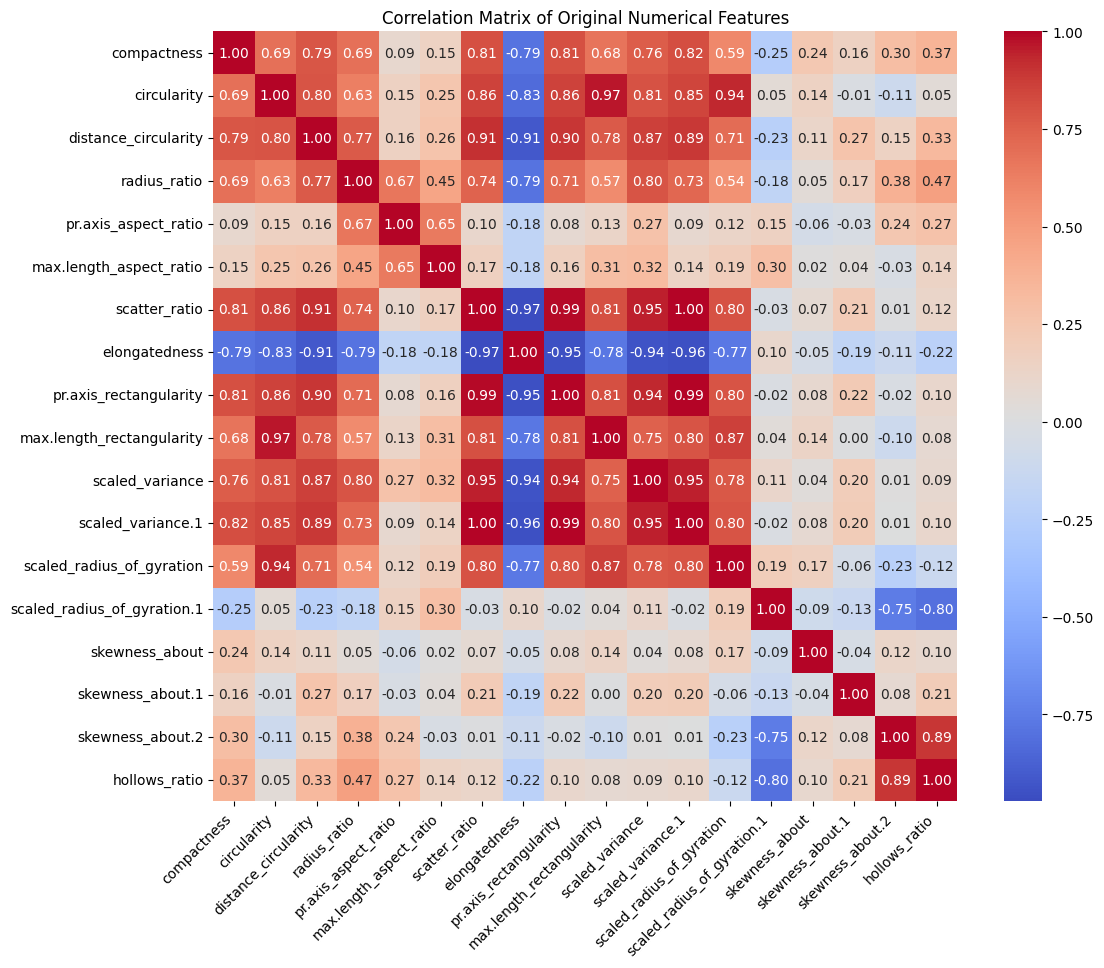

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make a copy of the original DataFrame to ensure no prior modifications affect it
df_original_numerical = df.select_dtypes(include=[np.number]).copy()

# Calculate the correlation matrix
correlation_matrix_original = df_original_numerical.corr()

# Plot the correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_original, annot=True, cmap='coolwarm', fmt=".2f")
plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for readability
plt.title("Correlation Matrix of Original Numerical Features")
plt.show()

#### **Visualizing Highly Correlated Features**

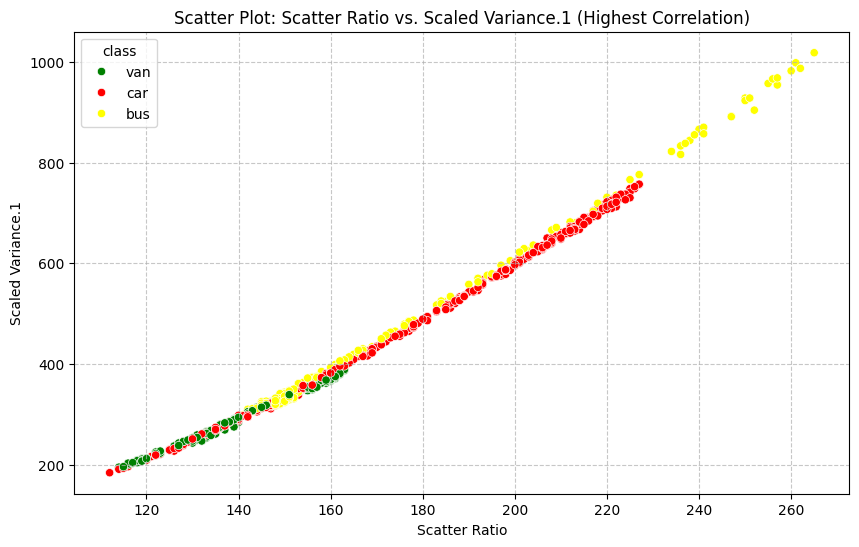

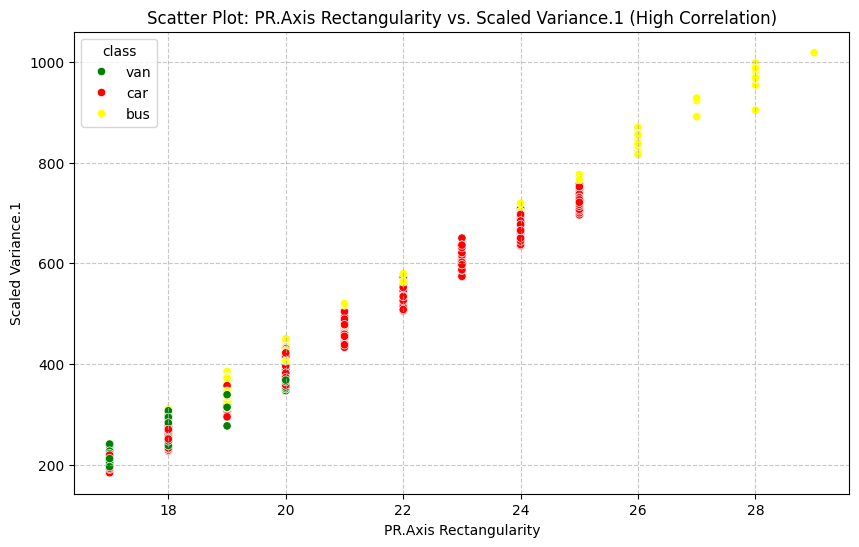

In [7]:
#Visualizing Highly Correlated Features
custom_palette = {'car': 'red', 'van': 'green', 'bus': 'yellow'}

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='scatter_ratio', y='scaled_variance.1', hue='class', palette=custom_palette)
plt.title('Scatter Plot: Scatter Ratio vs. Scaled Variance.1 (Highest Correlation)')
plt.xlabel('Scatter Ratio')
plt.ylabel('Scaled Variance.1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pr.axis_rectangularity', y='scaled_variance.1', hue='class', palette=custom_palette)
plt.title('Scatter Plot: PR.Axis Rectangularity vs. Scaled Variance.1 (High Correlation)')
plt.xlabel('PR.Axis Rectangularity')
plt.ylabel('Scaled Variance.1')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [8]:
import numpy as np

# Get the absolute values of the correlation matrix
abs_corr_matrix = correlation_matrix_original.abs()

# Select the upper triangle to avoid duplicates and self-correlations
upper_tri = abs_corr_matrix.where(np.triu(np.ones(abs_corr_matrix.shape), k=1).astype(bool))

# Find feature pairs with very strong correlations (e.g., absolute correlation > 0.9)
highest_corr_pairs = upper_tri[upper_tri > 0.9].stack().sort_values(ascending=False)

print("Features with the highest linear continuous distribution (absolute correlation > 0.9):")
display(highest_corr_pairs)

Features with the highest linear continuous distribution (absolute correlation > 0.9):


scatter_ratio           scaled_variance.1            0.996328
pr.axis_rectangularity  scaled_variance.1            0.992316
scatter_ratio           pr.axis_rectangularity       0.992078
                        elongatedness                0.973504
circularity             max.length_rectangularity    0.965729
elongatedness           scaled_variance.1            0.956488
scatter_ratio           scaled_variance              0.951672
elongatedness           pr.axis_rectangularity       0.950405
scaled_variance         scaled_variance.1            0.949766
elongatedness           scaled_variance              0.938313
pr.axis_rectangularity  scaled_variance              0.938182
circularity             scaled_radius_of_gyration    0.935950
distance_circularity    elongatedness                0.913020
                        scatter_ratio                0.907949
dtype: float64

#### Conclusions from Highly Correlated Features:

*   **Strong Linear Trend:** As seen in the plots (e.g., 'scatter_ratio' vs. 'scaled_variance.1'), highly correlated features tend to follow a clear linear pattern. When one feature increases, the other tends to increase (positive correlation) or decrease (negative correlation) predictably.
*   **Redundancy:** Features with very high correlation might be measuring similar aspects of the data. In modeling tasks, one of these highly correlated features could potentially be removed to reduce dimensionality without significant loss of information, especially if multicollinearity is a concern.
*   **Classification Insights:** The separation of 'class' groups (car, bus, van) might be more distinct along the direction of this strong linear trend, suggesting these correlated features are good indicators for differentiating vehicle types.

#### **Lowest Correlation with Scatter Plot**

In [9]:
import numpy as np

# Get the absolute values of the correlation matrix
abs_corr_matrix = correlation_matrix_original.abs()

# Select the lower triangle to avoid duplicates and self-correlations
lower_tri = abs_corr_matrix.where(np.triu(np.ones(abs_corr_matrix.shape), k=1).astype(bool))

# Find feature pairs with very weak correlations (e.g., absolute correlation > 0.01 and < 0.1)
lowest_corr_pairs = lower_tri[(lower_tri > 0.01) & (lower_tri < 0.1)].stack().sort_values(ascending=True)

print("Features with very low linear correlation (absolute correlation between 0.01 and 0.1):")
display(lowest_corr_pairs)

Features with very low linear correlation (absolute correlation between 0.01 and 0.1):


,,0
circularity,skewness_about.1,0.011869
scaled_variance,skewness_about.2,0.014434
max.length_aspect_ratio,skewness_about,0.015446
pr.axis_rectangularity,scaled_radius_of_gyration.1,0.015711
scaled_variance.1,scaled_radius_of_gyration.1,0.016642
pr.axis_rectangularity,skewness_about.2,0.019066
max.length_aspect_ratio,skewness_about.2,0.026184
scatter_ratio,scaled_radius_of_gyration.1,0.028006
pr.axis_aspect_ratio,skewness_about.1,0.032180
skewness_about,skewness_about.1,0.035154


Text(0, 0.5, 'Skewness about.2')

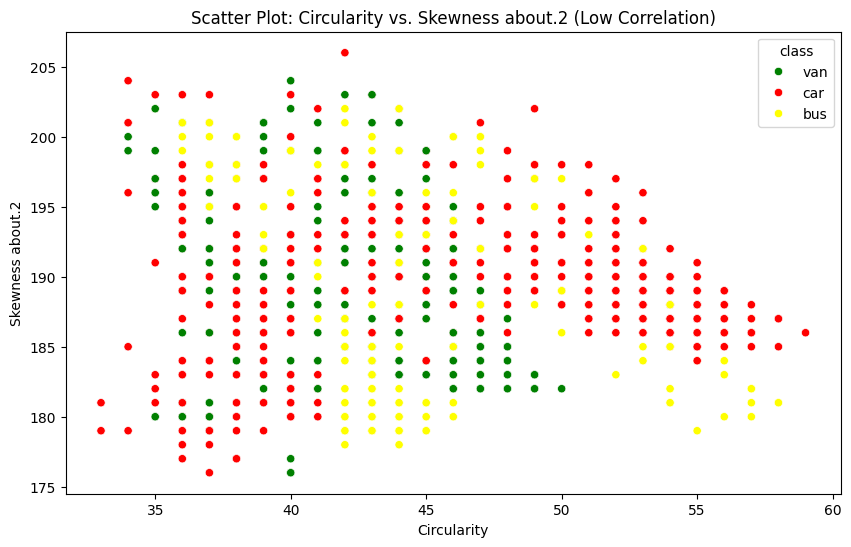

In [10]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='circularity', y='skewness_about.2', hue='class', palette=custom_palette)
plt.title('Scatter Plot: Circularity vs. Skewness about.2 (Low Correlation)')
plt.xlabel('Circularity')
plt.ylabel('Skewness about.2')

Text(0, 0.5, 'Skewness about.1')

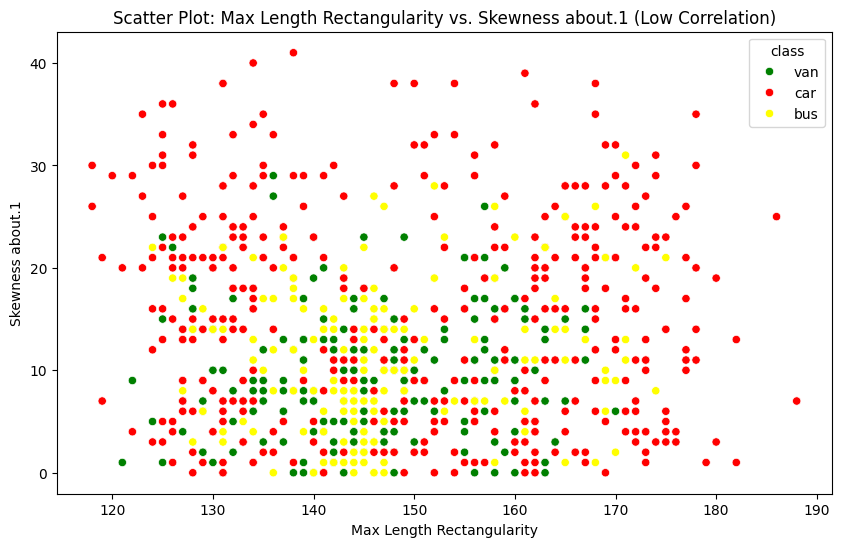

In [11]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='max.length_rectangularity', y='skewness_about.1', hue='class', palette=custom_palette)
plt.title('Scatter Plot: Max Length Rectangularity vs. Skewness about.1 (Low Correlation)')
plt.xlabel('Max Length Rectangularity')
plt.ylabel('Skewness about.1')

## **1.2 Checking & Handling Missing Values**

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  841 non-null    float64
 2   distance_circularity         842 non-null    float64
 3   radius_ratio                 840 non-null    float64
 4   pr.axis_aspect_ratio         844 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                845 non-null    float64
 7   elongatedness                845 non-null    float64
 8   pr.axis_rectangularity       843 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              843 non-null    float64
 11  scaled_variance.1            844 non-null    float64
 12  scaled_radius_of_gyration    844 non-null    float64
 13  scaled_radius_of_gyr

In [13]:
df.isnull().sum()

,0
compactness,0
circularity,5
distance_circularity,4
radius_ratio,6
pr.axis_aspect_ratio,2
max.length_aspect_ratio,0
scatter_ratio,1
elongatedness,1
pr.axis_rectangularity,3
max.length_rectangularity,0


In [14]:
#Total Missing Values
print(df.isnull().sum().sum())

41


In [15]:
#check duplicates
df.duplicated().sum()

np.int64(0)

In [16]:
#df.dropna(inplace=True)
#df.reset_index(drop=True, inplace=True)

- **replaced Missing Values with the median**

In [17]:
#replace Missing Values with the median
for column in df.columns:
    if df[column].isnull().any():
        if df[column].dtype in ['int64', 'float64']:
            df[column] = df[column].fillna(df[column].median())
            print(f"Column '{column}' replace with the the median value.")

print("Chech missing Values after replace it:")
display(df.isnull().sum())

Column 'circularity' replace with the the median value.
Column 'distance_circularity' replace with the the median value.
Column 'radius_ratio' replace with the the median value.
Column 'pr.axis_aspect_ratio' replace with the the median value.
Column 'scatter_ratio' replace with the the median value.
Column 'elongatedness' replace with the the median value.
Column 'pr.axis_rectangularity' replace with the the median value.
Column 'scaled_variance' replace with the the median value.
Column 'scaled_variance.1' replace with the the median value.
Column 'scaled_radius_of_gyration' replace with the the median value.
Column 'scaled_radius_of_gyration.1' replace with the the median value.
Column 'skewness_about' replace with the the median value.
Column 'skewness_about.1' replace with the the median value.
Column 'skewness_about.2' replace with the the median value.
Chech missing Values after replace it:


,0
compactness,0
circularity,0
distance_circularity,0
radius_ratio,0
pr.axis_aspect_ratio,0
max.length_aspect_ratio,0
scatter_ratio,0
elongatedness,0
pr.axis_rectangularity,0
max.length_rectangularity,0


In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 846 entries, 0 to 845
Data columns (total 19 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   compactness                  846 non-null    int64  
 1   circularity                  846 non-null    float64
 2   distance_circularity         846 non-null    float64
 3   radius_ratio                 846 non-null    float64
 4   pr.axis_aspect_ratio         846 non-null    float64
 5   max.length_aspect_ratio      846 non-null    int64  
 6   scatter_ratio                846 non-null    float64
 7   elongatedness                846 non-null    float64
 8   pr.axis_rectangularity       846 non-null    float64
 9   max.length_rectangularity    846 non-null    int64  
 10  scaled_variance              846 non-null    float64
 11  scaled_variance.1            846 non-null    float64
 12  scaled_radius_of_gyration    846 non-null    float64
 13  scaled_radius_of_gyr

In [19]:
df.shape

(846, 19)

### Removing one Highly Correlated Column

To address multicollinearity and simplify the dataset, we will remove one of the features from the pair with the highest correlation. We've identified `scatter_ratio` and `scaled_variance.1` as having the highest correlation (0.996). We will remove `scaled_variance.1`.

# **New DataFrame df_cleaned**

In [20]:
df_cleaned = df.drop(columns=['scaled_variance.1'])
print("New DataFrame shape:", df_cleaned.shape)

New DataFrame shape: (846, 18)


In [21]:
df_cleaned_to_csv = df_cleaned.to_csv('df_cleaned.csv', index=False)

In [22]:
df_cleaned

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,class
0,95,48.0,83.0,178.0,72.0,10,162.0,42.0,20.0,159,176.0,184.0,70.0,6.0,16.0,187.0,197,van
1,91,41.0,84.0,141.0,57.0,9,149.0,45.0,19.0,143,170.0,158.0,72.0,9.0,14.0,189.0,199,van
2,104,50.0,106.0,209.0,66.0,10,207.0,32.0,23.0,158,223.0,220.0,73.0,14.0,9.0,188.0,196,car
3,93,41.0,82.0,159.0,63.0,9,144.0,46.0,19.0,143,160.0,127.0,63.0,6.0,10.0,199.0,207,van
4,85,44.0,70.0,205.0,103.0,52,149.0,45.0,19.0,144,241.0,188.0,127.0,9.0,11.0,180.0,183,bus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
841,93,39.0,87.0,183.0,64.0,8,169.0,40.0,20.0,134,200.0,149.0,72.0,7.0,25.0,188.0,195,car
842,89,46.0,84.0,163.0,66.0,11,159.0,43.0,20.0,159,173.0,176.0,72.0,1.0,20.0,186.0,197,van
843,106,54.0,101.0,222.0,67.0,12,222.0,30.0,25.0,173,228.0,200.0,70.0,3.0,4.0,187.0,201,car
844,86,36.0,78.0,146.0,58.0,7,135.0,50.0,18.0,124,155.0,148.0,66.0,0.0,25.0,190.0,195,car


## **1.3 Outliers**

### Displaying Actual Outlier Values for Remaining Columns

Now, let's identify and display the specific outlier values for each of the columns that still contain them, based on the Interquartile Range (IQR) method and the current state of our DataFrame.

In [23]:
import pandas as pd

# Select only numerical columns for outlier detection from the CURRENT df
numerical_cols = df_cleaned.select_dtypes(include=[np.number]).columns

outlier_values_data = []
columns_with_new_outliers = []

for col in numerical_cols:
    Q1 = df_cleaned[col].quantile(0.25)
    Q3 = df_cleaned[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = df_cleaned[(df_cleaned[col] < lower_bound) | (df_cleaned[col] > upper_bound)]

    if not outliers.empty:
        columns_with_new_outliers.append(col)
        print(f"\n--- Outliers for feature: {col} ---")
        display(outliers[['class', col]])

if not columns_with_new_outliers:
    print("No columns found with outliers based on the IQR method in the current DataFrame.")


--- Outliers for feature: radius_ratio ---


,class,radius_ratio
37,van,306.0
135,van,322.0
388,van,333.0



--- Outliers for feature: pr.axis_aspect_ratio ---


,class,pr.axis_aspect_ratio
4,bus,103.0
37,van,126.0
100,bus,126.0
135,van,133.0
291,van,102.0
388,van,138.0
523,van,97.0
706,van,105.0



--- Outliers for feature: max.length_aspect_ratio ---


...

,class,scaled_radius_of_gyration.1
4,bus,127.0
37,van,118.0
47,bus,88.0
79,bus,88.0
100,bus,119.0
135,van,97.0
230,van,89.0
291,van,90.0
381,bus,88.0
388,van,135.0



--- Outliers for feature: skewness_about ---


,class,skewness_about
44,car,20.0
113,car,21.0
123,car,22.0
190,car,20.0
346,car,21.0
400,car,21.0
505,car,21.0
516,car,22.0
623,car,22.0
761,car,22.0



--- Outliers for feature: skewness_about.1 ---


,class,skewness_about.1
132,car,41.0


###**Checking the Relationship between Outliers and the Target Variable ('class')**

To understand how outliers are distributed by vehicle class, we will visualize box plots for each column with outliers, separating the data by the variable 'class'.

Generate box plots for columns with outliers, grouped by 'class':


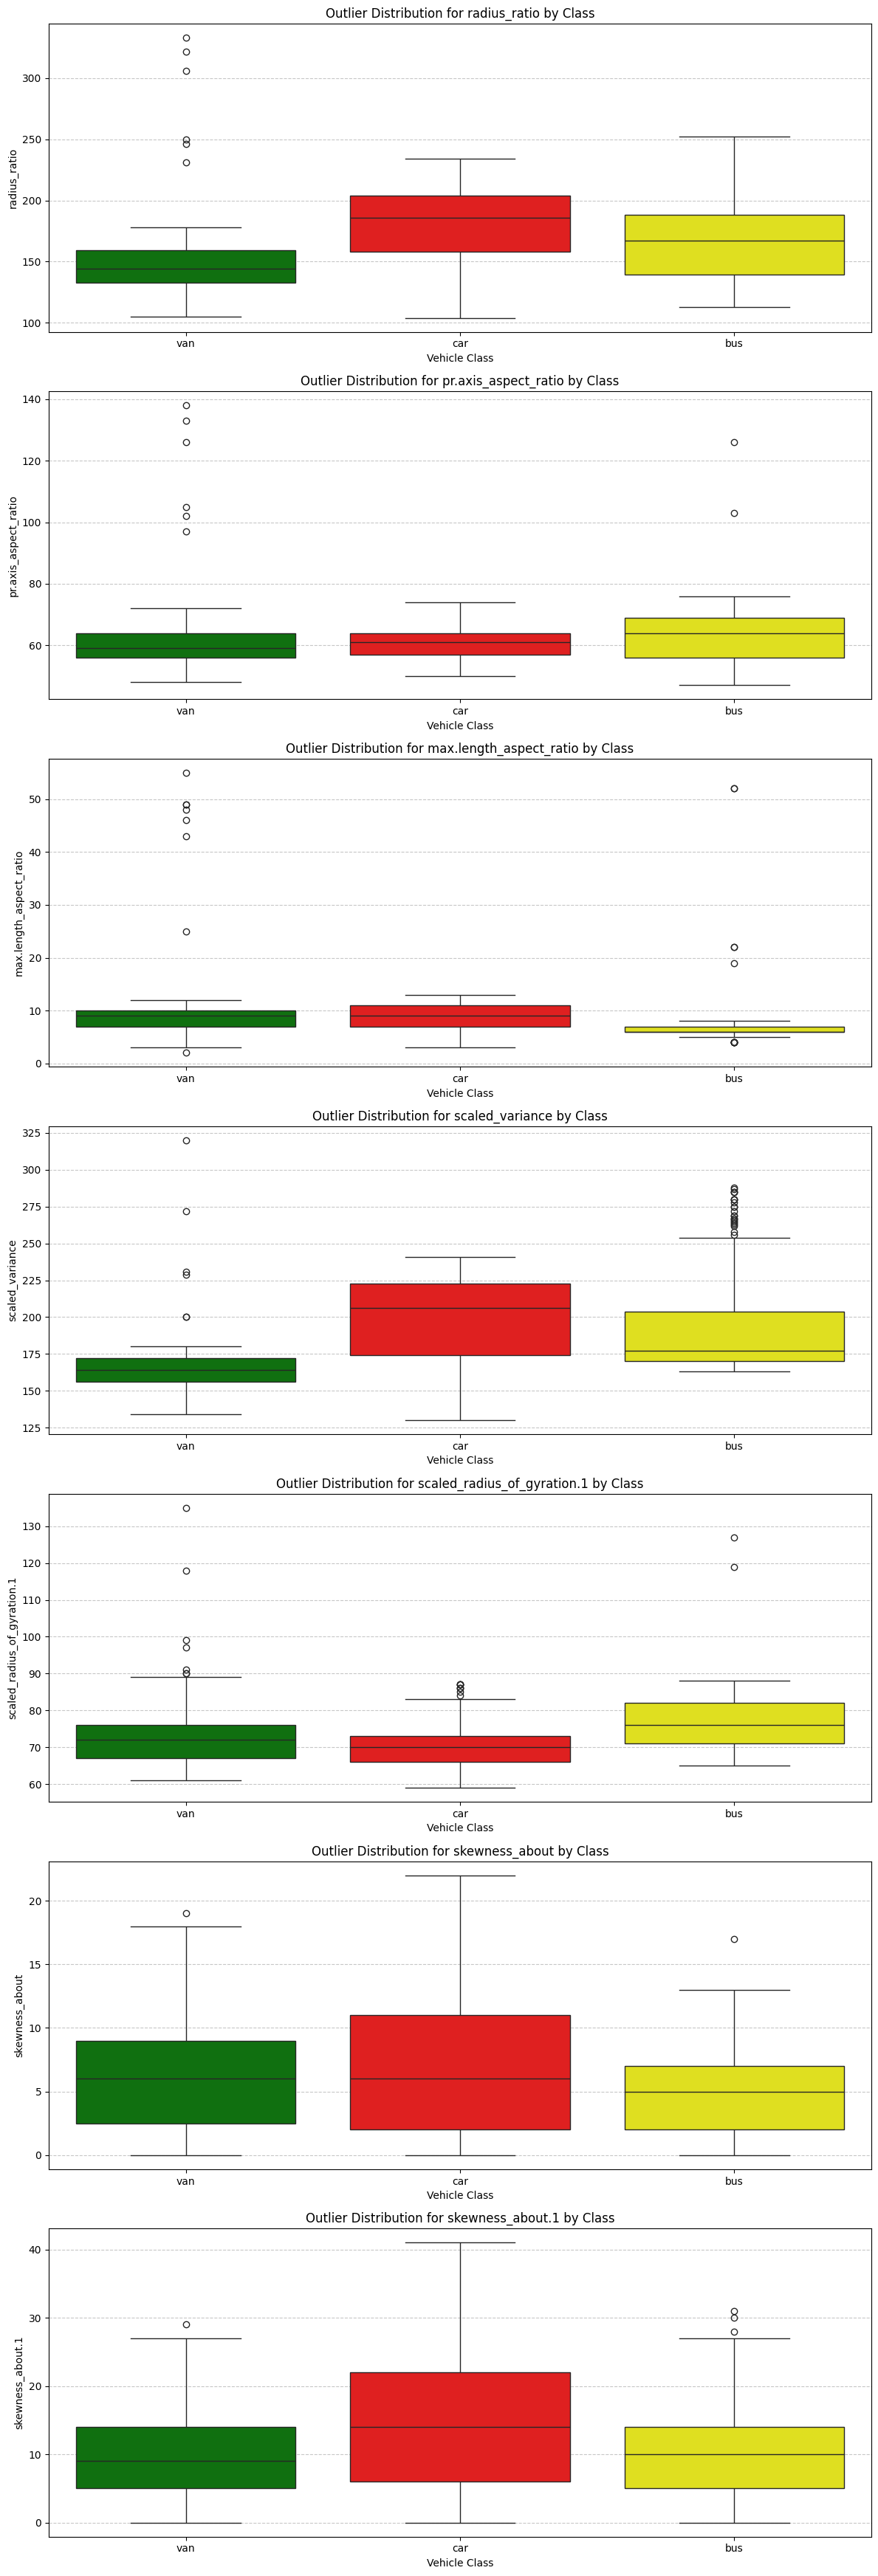

In [24]:
if 'columns_with_new_outliers' in locals() and columns_with_new_outliers:
    print("Generate box plots for columns with outliers, grouped by 'class':")
    plt.figure(figsize=(12, 5 * len(columns_with_new_outliers)))
    for i, col in enumerate(columns_with_new_outliers):
        plt.subplot(len(columns_with_new_outliers), 1, i + 1)
        sns.boxplot(x='class', y=col, data=df_cleaned, palette=custom_palette, hue='class', legend=False)
        plt.title(f'Outlier Distribution for {col} by Class')
        plt.xlabel('Vehicle Class')
        plt.ylabel(col)
        plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("No outlier columns were identified to view the class distribution.")

In [25]:
print(columns_with_new_outliers)

['radius_ratio', 'pr.axis_aspect_ratio', 'max.length_aspect_ratio', 'scaled_variance', 'scaled_radius_of_gyration.1', 'skewness_about', 'skewness_about.1']


- **Constant presence of outliers** in a certain class for a certain characteristic can be a distinctive feature of that class,** not necessarily a data error.**

Looking at the box plots grouped by 'class', can notice :
- **class 'van'**consistently shows outliers for **radius_ratio** feature.
This observation suggests that these "outliers" might not be mistakes or anomalies in the data, but rather inherent characteristics that define that specific vehicle class.

- **should keep it**.

###### **When outliers are distinctive features of a class, blindly removing them can lead to a loss of valuable information that helps differentiate between classes**.

# **2. Supervised learning**

## **2.1 Supervised Model**

#### **2.1.1 Random Forest Classifier without outlier treatment**
- evaluate performance.
- baseline for comparison.

In [26]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Separate features (X) and target (y)
X = df_cleaned.drop('class', axis=1)
y = df_cleaned['class']

# Encode the target variable 'class'
le = LabelEncoder()
y_encoded = le.fit_transform(y)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convert scaled arrays back to DataFrames with column names for clarity (optional, but good for inspection)
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns)

print("Data preparation complete for baseline model.")

Data preparation complete for baseline model.


In [27]:
# Initialize and train the Random Forest Classifier
rf_model_baseline = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_baseline.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_baseline = rf_model_baseline.predict(X_test_scaled)
y_prob_baseline = rf_model_baseline.predict_proba(X_test_scaled)

# Evaluate the model
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
report_baseline = classification_report(y_test, y_pred_baseline, target_names=le.classes_)
conf_matrix_baseline = confusion_matrix(y_test, y_pred_baseline)

print("--- Random Forest Model Performance (Without Outlier Treatment) ---")
print(f"Accuracy: {accuracy_baseline:.4f}")
print("\nClassification Report:")
print(report_baseline)
print("\nConfusion Matrix:")
print(conf_matrix_baseline)

# Calculate ROC AUC for each class (one-vs-rest)
roc_auc_scores_baseline = []
for i in range(len(le.classes_)):
    roc_auc_scores_baseline.append(roc_auc_score(y_test == i, y_prob_baseline[:, i]))

print("\nROC AUC per class:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {roc_auc_scores_baseline[i]:.4f}")

# Store results for comparison
results_baseline = {
    'Accuracy': accuracy_baseline,
    'Classification Report': report_baseline,
    'Confusion Matrix': conf_matrix_baseline,
    'ROC AUC per class': dict(zip(le.classes_, roc_auc_scores_baseline))
}

--- Random Forest Model Performance (Without Outlier Treatment) ---
Accuracy: 0.9706

Classification Report:
              precision    recall  f1-score   support

         bus       1.00      0.98      0.99        52
         car       0.97      0.96      0.97        78
         van       0.93      0.97      0.95        40

    accuracy                           0.97       170
   macro avg       0.97      0.97      0.97       170
weighted avg       0.97      0.97      0.97       170


Confusion Matrix:
[[51  1  0]
 [ 0 75  3]
 [ 0  1 39]]

ROC AUC per class:
  bus: 0.9993
  car: 0.9964
  van: 0.9954


#### **2.1.2 Random Forest Classifier** on the new dataset **applying Winsorization  for outlier treatment**
- create a new DataFrame with treated outliers
- train and evaluate another Random Forest model on  treated data.

In [28]:
# Create a copy of the DataFrame for outlier treatment
df_treated = df_cleaned.copy()

# Apply Winsorization to columns identified with outliers
# We will cap values at the 5th and 95th percentiles (common practice for Winsorization)
for col in columns_with_new_outliers:
    lower_bound = df_treated[col].quantile(0.05)
    upper_bound = df_treated[col].quantile(0.95)
    df_treated[col] = df_treated[col].clip(lower=lower_bound, upper=upper_bound)

print("Outliers treated using Winsorization.")

# Separate features (X_treated) and target (y) from the treated DataFrame
X_treated = df_treated.drop('class', axis=1)
y_treated = df_treated['class'] # Target remains the same

# Encode the target variable 'class' (already done, but re-applying to treated y for consistency)
y_treated_encoded = le.transform(y_treated)

# Split treated data into training and testing sets
X_train_treated, X_test_treated, y_train_treated, y_test_treated = train_test_split(X_treated, y_treated_encoded, test_size=0.2, random_state=42)

# Scale numerical features of the treated data
# Initialize a new scaler to avoid data leakage from the baseline model's fit
scaler_treated = StandardScaler()
X_train_treated_scaled = scaler_treated.fit_transform(X_train_treated)
X_test_treated_scaled = scaler_treated.transform(X_test_treated)

print("Data preparation complete for model with outlier treatment.")

Outliers treated using Winsorization.
Data preparation complete for model with outlier treatment.


In [29]:
# Initialize and train the Random Forest Classifier on treated data
rf_model_treated = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_model_treated.fit(X_train_treated_scaled, y_train_treated)

# Make predictions on the test set of treated data
y_pred_treated = rf_model_treated.predict(X_test_treated_scaled)
y_prob_treated = rf_model_treated.predict_proba(X_test_treated_scaled)

# Evaluate the model
accuracy_treated = accuracy_score(y_test_treated, y_pred_treated)
report_treated = classification_report(y_test_treated, y_pred_treated, target_names=le.classes_)
conf_matrix_treated = confusion_matrix(y_test_treated, y_pred_treated)

print("--- Random Forest Model Performance (With Outlier Treatment) ---")
print(f"Accuracy: {accuracy_treated:.4f}")
print("\nClassification Report:")
print(report_treated)
print("\nConfusion Matrix:")
print(conf_matrix_treated)

# Calculate ROC AUC for each class (one-vs-rest)
roc_auc_scores_treated = []
for i in range(len(le.classes_)):
    roc_auc_scores_treated.append(roc_auc_score(y_test_treated == i, y_prob_treated[:, i]))

print("\nROC AUC per class:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {roc_auc_scores_treated[i]:.4f}")

# Store results for comparison
results_treated = {
    'Accuracy': accuracy_treated,
    'Classification Report': report_treated,
    'Confusion Matrix': conf_matrix_treated,
    'ROC AUC per class': dict(zip(le.classes_, roc_auc_scores_treated))
}

--- Random Forest Model Performance (With Outlier Treatment) ---
Accuracy: 0.9647

Classification Report:
              precision    recall  f1-score   support

         bus       1.00      0.98      0.99        52
         car       0.97      0.95      0.96        78
         van       0.91      0.97      0.94        40

    accuracy                           0.96       170
   macro avg       0.96      0.97      0.96       170
weighted avg       0.97      0.96      0.96       170


Confusion Matrix:
[[51  1  0]
 [ 0 74  4]
 [ 0  1 39]]

ROC AUC per class:
  bus: 0.9993
  car: 0.9971
  van: 0.9961


##### **Comparison of Random Forest Models**

Let's compare the performance metrics of the Random Forest model trained *without* outlier treatment against the one trained *with* outlier treatment (Winsorization).

In [30]:
print("### Performance Comparison ###")
print("\n--- Model Without Outlier Treatment ---")
print(f"Accuracy: {results_baseline['Accuracy']:.4f}")
print("ROC AUC per class:")
for class_name, score in results_baseline['ROC AUC per class'].items():
    print(f"  {class_name}: {score:.4f}")

print("\n--- Model With Outlier Treatment (Winsorization) ---")
print(f"Accuracy: {results_treated['Accuracy']:.4f}")
print("ROC AUC per class:")
for class_name, score in results_treated['ROC AUC per class'].items():
    print(f"  {class_name}: {score:.4f}")

print("\nBased on these metrics, you can observe whether outlier treatment improved, worsened, or had a negligible effect on the model's performance.")

### Performance Comparison ###

--- Model Without Outlier Treatment ---
Accuracy: 0.9706
ROC AUC per class:
  bus: 0.9993
  car: 0.9964
  van: 0.9954

--- Model With Outlier Treatment (Winsorization) ---
Accuracy: 0.9647
ROC AUC per class:
  bus: 0.9993
  car: 0.9971
  van: 0.9961

Based on these metrics, you can observe whether outlier treatment improved, worsened, or had a negligible effect on the model's performance.


**F1-Score** Comparison per Class

-  F1-score provides a balanced measure of precision and recall, and it's particularly useful for imbalanced datasets or when you want to evaluate a model's performance on a per-class basis.

In [31]:
from sklearn.metrics import classification_report

# Convert classification reports (strings) to dictionaries for easier access to F1-scores
report_dict_baseline = classification_report(y_test, y_pred_baseline, target_names=le.classes_, output_dict=True)
report_dict_treated = classification_report(y_test_treated, y_pred_treated, target_names=le.classes_, output_dict=True)

print("### F1-Score Comparison per Class ###")

print("\n--- Model Without Outlier Treatment ---")
for class_name in le.classes_:
    f1_score_baseline = report_dict_baseline[class_name]['f1-score']
    print(f"  F1-score for {class_name}: {f1_score_baseline:.4f}")

print("\n--- Model With Outlier Treatment (Winsorization) ---")
for class_name in le.classes_:
    f1_score_treated = report_dict_treated[class_name]['f1-score']
    print(f"  F1-score for {class_name}: {f1_score_treated:.4f}")

print("\nThis detailed breakdown allows you to see how each model performs for each specific vehicle class.")

### F1-Score Comparison per Class ###

--- Model Without Outlier Treatment ---
  F1-score for bus: 0.9903
  F1-score for car: 0.9677
  F1-score for van: 0.9512

--- Model With Outlier Treatment (Winsorization) ---
  F1-score for bus: 0.9903
  F1-score for car: 0.9610
  F1-score for van: 0.9398

This detailed breakdown allows you to see how each model performs for each specific vehicle class.


### Visualisations: **Random Forest (Without Outlier Treatment) vs Random Forest (With Outlier Treatment)**

Visualize key metrics for Model Random Forest (Without Outlier Treatment) and Random Forest (With Outlier Treatment) comparison

In [32]:
#Visualize key metrics for Model Random Forest (Without Outlier Treatment) and Random Forest (With Outlier Treatment) comparison
#prepare data for comparison
model_names = ['Random Forest (Without Outlier Treatment)', 'Random Forest (With Outlier Treatment)']
accuracies = [results_baseline['Accuracy'], results_treated['Accuracy']]

# Correctly retrieve the macro average F1-score from the classification report dictionaries
f1_scores_macro_avg = [report_dict_baseline['macro avg']['f1-score'], report_dict_treated['macro avg']['f1-score']]

# Create a DataFrame for comparison
comparison_df_rf = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
    'F1-score (Macro Avg)': f1_scores_macro_avg
})

print("Comparative Metrics for Random Forest Models:")
display(comparison_df_rf)

Comparative Metrics for Random Forest Models:


,Model,Accuracy,F1-score (Macro Avg)
0,Random Forest (Without Outlier Treatment),0.970588,0.969751
1,Random Forest (With Outlier Treatment),0.964706,0.963696


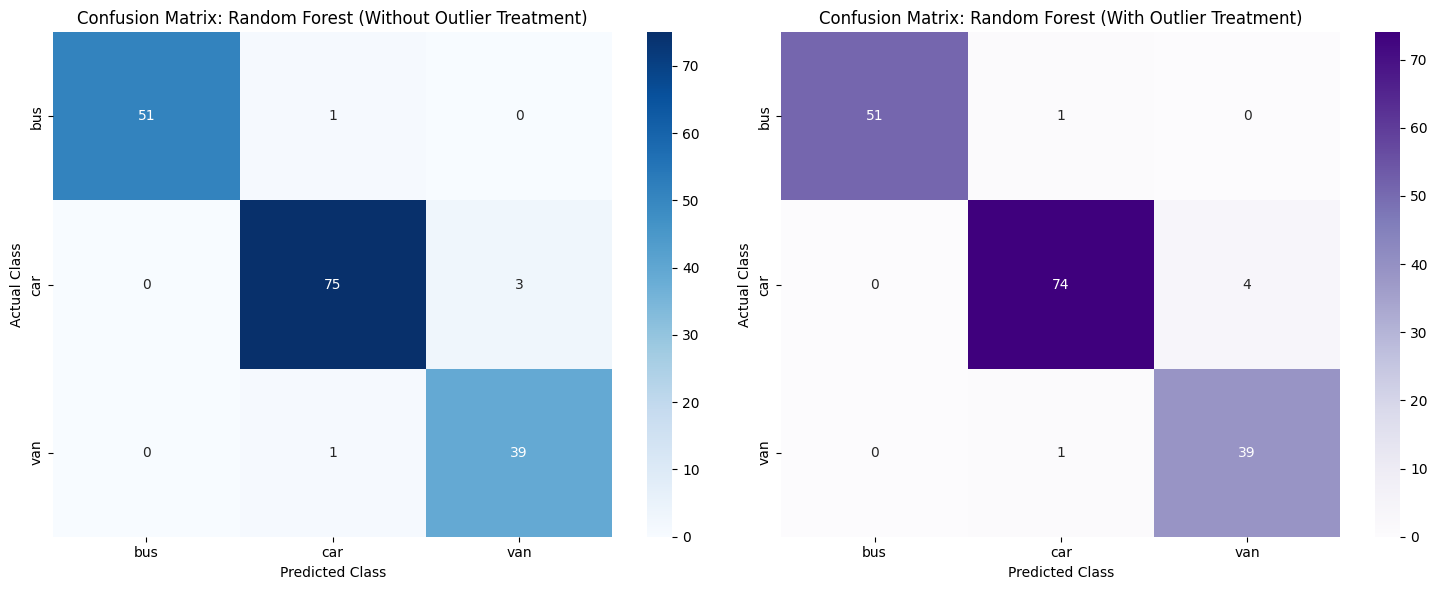

In [33]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.heatmap(conf_matrix_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Random Forest (Without Outlier Treatment)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.heatmap(conf_matrix_treated, annot=True, fmt='d', cmap='Purples', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Random Forest (With Outlier Treatment)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

###**2.1.3 Logistic Regression**

- train and evaluate a Logistic Regression model on the same scaled dataset used for the basic Random Forest model (without treating outliers).

This will allow us to compare the performance of a linear model with that of a tree-based model.

In [34]:
from sklearn.linear_model import LogisticRegression

# Initialize and train the Logistic Regression Classifier
# Using 'liblinear' solver for multiclass classification with L1/L2 regularization
# 'class_weight="balanced"' helps handle potential class imbalance
lr_model = LogisticRegression(solver='liblinear', random_state=42, multi_class='ovr', class_weight='balanced')
lr_model.fit(X_train_scaled, y_train)

# Make predictions on the test set
y_pred_lr = lr_model.predict(X_test_scaled)
y_prob_lr = lr_model.predict_proba(X_test_scaled)

# Evaluate the model
accuracy_lr = accuracy_score(y_test, y_pred_lr)
report_lr = classification_report(y_test, y_pred_lr, target_names=le.classes_)
conf_matrix_lr = confusion_matrix(y_test, y_pred_lr)

print("--- Logistic Regression Model Performance ---")
print(f"Accuracy: {accuracy_lr:.4f}")
print("\nClassification Report:")
print(report_lr)
print("\nConfusion Matrix:")
print(conf_matrix_lr)

# Calculate ROC AUC for each class (one-vs-rest)
roc_auc_scores_lr = []
for i in range(len(le.classes_)):
    roc_auc_scores_lr.append(roc_auc_score(y_test == i, y_prob_lr[:, i]))

print("\nROC AUC per class:")
for i, class_name in enumerate(le.classes_):
    print(f"  {class_name}: {roc_auc_scores_lr[i]:.4f}")

# Store results for comparison
results_lr = {
    'Accuracy': accuracy_lr,
    'Classification Report': report_lr,
    'Confusion Matrix': conf_matrix_lr,
    'ROC AUC per class': dict(zip(le.classes_, roc_auc_scores_lr))
}

--- Logistic Regression Model Performance ---
Accuracy: 0.9235

Classification Report:
              precision    recall  f1-score   support

         bus       0.90      0.90      0.90        52
         car       0.96      0.90      0.93        78
         van       0.89      1.00      0.94        40

    accuracy                           0.92       170
   macro avg       0.92      0.93      0.92       170
weighted avg       0.93      0.92      0.92       170


Confusion Matrix:
[[47  3  2]
 [ 5 70  3]
 [ 0  0 40]]

ROC AUC per class:
  bus: 0.9814
  car: 0.9760
  van: 0.9987


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


####**Random Forest Classifier without outlier treatment** vs **Logistic Regression**

In [35]:
print("### Model Performance Comparison ###")

print("\n--- Random Forest Model (Without Outlier Treatment) ---")
print(f"Accuracy: {results_baseline['Accuracy']:.4f}")
print("ROC AUC per class:")
for class_name, score in results_baseline['ROC AUC per class'].items():
    print(f"  {class_name}: {score:.4f}")
report_dict_baseline = classification_report(y_test, y_pred_baseline, target_names=le.classes_, output_dict=True)
print("F1-score per class:")
for class_name in le.classes_:
    f1_score_baseline = report_dict_baseline[class_name]['f1-score']
    print(f"  {class_name}: {f1_score_baseline:.4f}")
print("Confusion Matrix:\n", conf_matrix_baseline)

print("\n--- Logistic Regression Model ---")
print(f"Accuracy: {results_lr['Accuracy']:.4f}")
print("ROC AUC per class:")
for class_name, score in results_lr['ROC AUC per class'].items():
    print(f"  {class_name}: {score:.4f}")
report_dict_lr = classification_report(y_test, y_pred_lr, target_names=le.classes_, output_dict=True)
print("F1-score per class:")
for class_name in le.classes_:
    f1_score_lr = report_dict_lr[class_name]['f1-score']
    print(f"  {class_name}: {f1_score_lr:.4f}")
print("Confusion Matrix:\n", conf_matrix_lr)

print("\nAnalyze these metrics to understand the performance differences between the two types of models.")

### Model Performance Comparison ###

--- Random Forest Model (Without Outlier Treatment) ---
Accuracy: 0.9706
ROC AUC per class:
  bus: 0.9993
  car: 0.9964
  van: 0.9954
F1-score per class:
  bus: 0.9903
  car: 0.9677
  van: 0.9512
Confusion Matrix:
 [[51  1  0]
 [ 0 75  3]
 [ 0  1 39]]

--- Logistic Regression Model ---
Accuracy: 0.9235
ROC AUC per class:
  bus: 0.9814
  car: 0.9760
  van: 0.9987
F1-score per class:
  bus: 0.9038
  car: 0.9272
  van: 0.9412
Confusion Matrix:
 [[47  3  2]
 [ 5 70  3]
 [ 0  0 40]]

Analyze these metrics to understand the performance differences between the two types of models.


Visualize key metrics for Model Comparison.

In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for comparison
model_names = ['Random Forest (Baseline)', 'Logistic Regression']
accuracies = [results_baseline['Accuracy'], results_lr['Accuracy']]

# Extract F1-scores per class
f1_scores_baseline = [report_dict_baseline[cls]['f1-score'] for cls in le.classes_]
f1_scores_lr = [report_dict_lr[cls]['f1-score'] for cls in le.classes_]

# Create DataFrame for comparison
comparison_df = pd.DataFrame({
    'Model': model_names,
    'Accuracy': accuracies,
})

# Add F1-scores for each class to the DataFrame
for i, cls in enumerate(le.classes_):
    comparison_df[f'F1-score {cls}'] = [f1_scores_baseline[i], f1_scores_lr[i]]

# Extract ROC AUC scores per class
roc_auc_baseline = list(results_baseline['ROC AUC per class'].values())
roc_auc_lr = list(results_lr['ROC AUC per class'].values())

for i, cls in enumerate(le.classes_):
    comparison_df[f'ROC AUC {cls}'] = [roc_auc_baseline[i], roc_auc_lr[i]]

print("Comparative Metrics:")
display(comparison_df)


Comparative Metrics:


,Model,Accuracy,F1-score bus,F1-score car,F1-score van,ROC AUC bus,ROC AUC car,ROC AUC van
0,Random Forest (Baseline),0.970588,0.990291,0.967742,0.951220,0.999267,0.996377,0.995385
1,Logistic Regression,0.923529,0.903846,0.927152,0.941176,0.981421,0.976031,0.998654


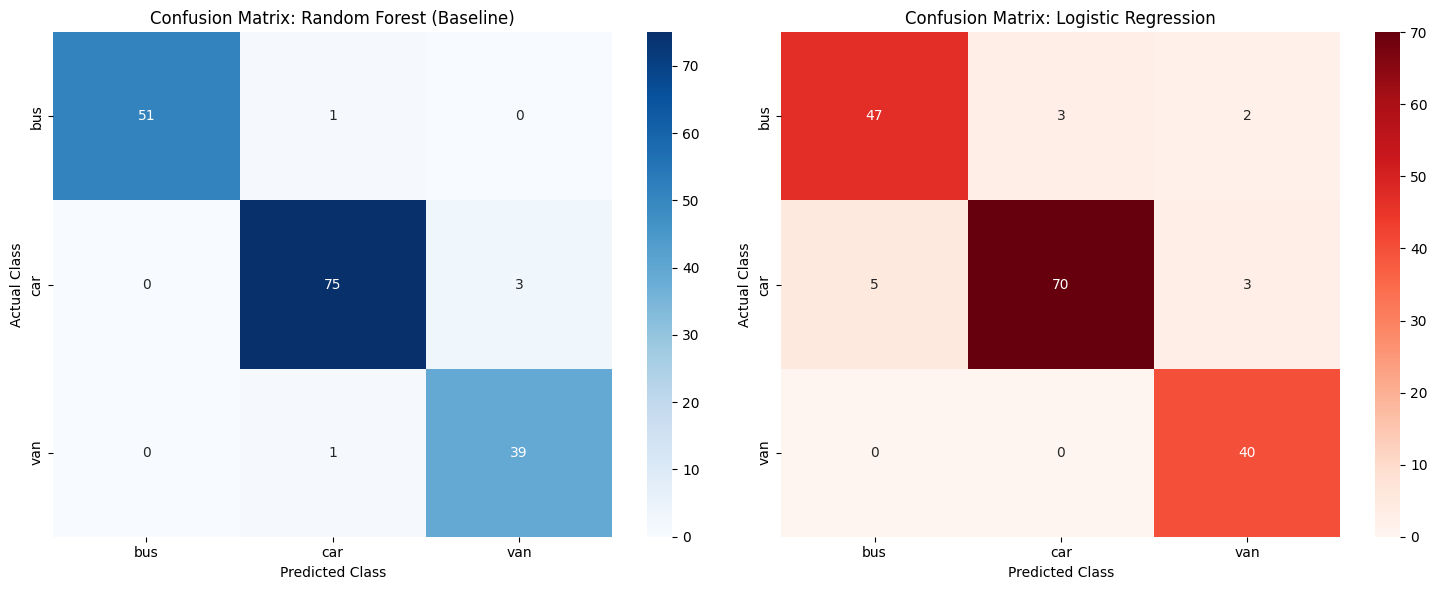

In [37]:
plt.figure(figsize=(15, 6))

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.heatmap(conf_matrix_baseline, annot=True, fmt='d', cmap='Blues', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Random Forest (Baseline)')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.heatmap(conf_matrix_lr, annot=True, fmt='d', cmap='Reds', xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix: Logistic Regression')
plt.xlabel('Predicted Class')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()

Based on the comparison of the Random Forest (baseline) and Logistic Regression models, here is a summary:

Overall Performance: The Random Forest (baseline) model generally outperformed the Logistic Regression model across most metrics.
Accuracy: The Random Forest model achieved a higher accuracy of 0.9706 compared to the Logistic Regression model's 0.9235.
F1-Score per Class: The Random Forest model showed higher F1-scores for 'bus' (0.9903) and 'car' (0.9677), while the Logistic Regression model had lower F1-scores for 'bus' (0.9038) and 'car' (0.9272). For 'van', Random Forest had 0.9512 and Logistic Regression had 0.9412.
ROC AUC per Class: Both models showed strong ROC AUC scores, with Random Forest having slightly higher or comparable scores for 'bus' (0.9993) and 'car' (0.9964) compared to Logistic Regression's 'bus' (0.9814) and 'car' (0.9760). Logistic Regression had a slightly higher ROC AUC for 'van' (0.9987) than Random Forest (0.9954).
Outlier Treatment: The Random Forest model trained with Winsorization (outlier treatment) showed a slight decrease in accuracy (0.9647) and some F1-scores compared to the baseline Random Forest, suggesting that for this dataset and model, aggressive outlier treatment was not beneficial and the model was robust to them.
In conclusion, the Random Forest (baseline) model (without explicit outlier treatment) proved to be the most effective for this classification task, demonstrating better overall predictive power

#### Feature Importance for Random Forest (Baseline) Model

Let's visualize the importance of each feature in the Random Forest model to understand their contribution to the classification task.

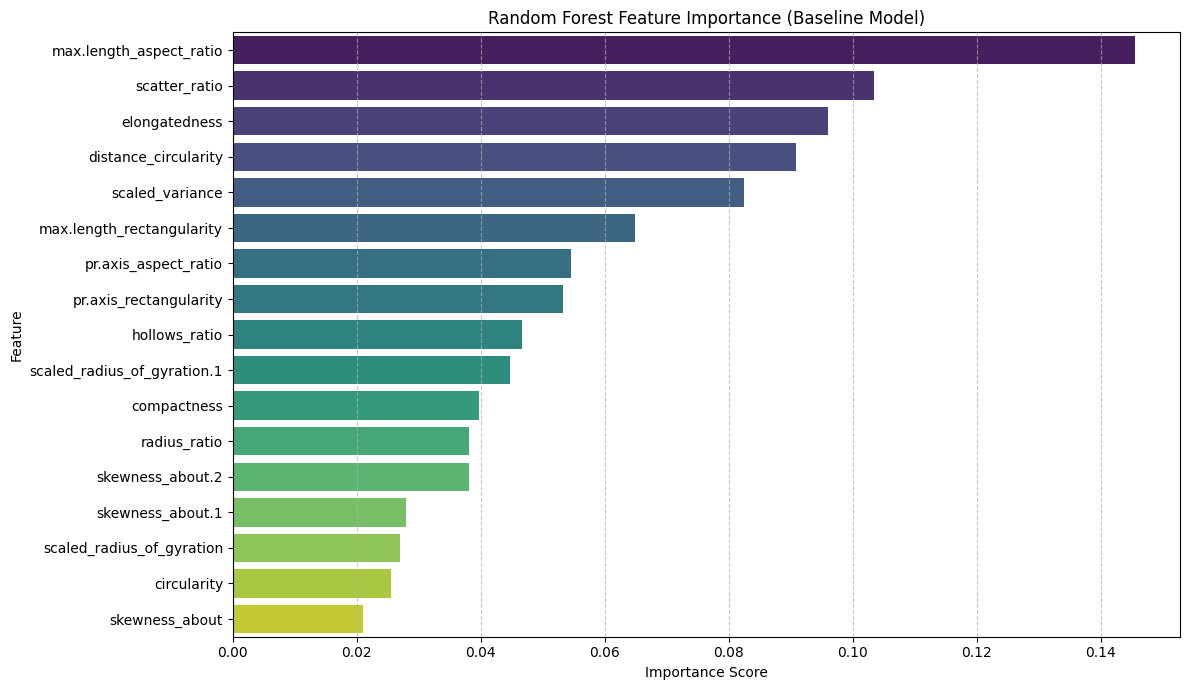

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances from the trained Random Forest model
feature_importances = rf_model_baseline.feature_importances_

# Create a DataFrame to hold features and their importance scores
feature_names = X.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': feature_importances})

# Sort the features by importance in descending order
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# Plot the feature importances
plt.figure(figsize=(12, 7))
sns.barplot(x='Importance', y='Feature', data=importance_df, palette='viridis', hue='Feature', legend=False)
plt.title('Random Forest Feature Importance (Baseline Model)')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## **2.2 Summary: Vehicle Classification with Supervised Model**

This report summarizes the key steps taken in the vehicle classification analysis, from data preparation and exploration to the training and evaluation of different machine learning models, including the impact of outlier treatment.

**Data Preparation and Cleaning**

*   **Initial Data Load**: The `vehicle.csv` dataset was loaded, containing 846 entries and 19 features.
*   **Missing Values**: 41 missing values were identified across various numerical columns. These were imputed using the median of their respective columns.
*   **Feature Selection (Multicollinearity)**: An analysis of the correlation matrix revealed a very strong correlation (0.996) between `scatter_ratio` and `scaled_variance.1`. To reduce multicollinearity and simplify the model, `scaled_variance.1` was removed from the dataset.

**Outlier Analysis and Treatment**

*   **Outlier Detection**: Outliers were identified using the Interquartile Range (IQR) method in several numerical columns (`radius_ratio`, `pr.axis_aspect_ratio`, `max.length_aspect_ratio`, `scaled_variance`, `scaled_radius_of_gyration.1`, `skewness_about`, `skewness_about.1`).
*   **Relationship with Target Variable**: Box plots grouped by the 'class' variable showed that many identified 'outliers' were actually characteristic features of specific vehicle classes (e.g., certain `radius_ratio` values for 'van'). This suggested that these values might be discriminative rather than errors.
*   **Winsorization**: Winsorization (capping values at the 5th and 95th percentiles) was applied to the identified outlier columns to create a `df_treated` dataset.

**Model Training and Evaluation**

Three classification models were trained and evaluated:

2.1.1 Random Forest Classifier (Baseline - No Outlier Treatment)

*   **Training**: A Random Forest Classifier was trained on the scaled dataset without any explicit outlier treatment.
*   **Performance**:
    *   **Accuracy**: 0.9706
    *   **ROC AUC per class**: bus: 0.9993, car: 0.9964, van: 0.9954
    *   **F1-score per class**: bus: 0.9903, car: 0.9677, van: 0.9512
    *   **Confusion Matrix**: Showed excellent performance with only a few misclassifications (e.g., 1 'bus' classified as 'car', 3 'car' as 'van').

2.1.2. Random Forest Classifier (With Outlier Treatment - Winsorization)

*   **Training**: A Random Forest Classifier was trained on the scaled and Winsorized dataset.
*   **Performance**:
    *   **Accuracy**: 0.9647
    *   **ROC AUC per class**: bus: 0.9993, car: 0.9971, van: 0.9961
    *   **F1-score per class**: bus: 0.9903, car: 0.9610, van: 0.9398
*   **Comparison to Baseline**: The performance was slightly lower or comparable to the baseline model. This indicates that for the Random Forest, aggressive outlier treatment through Winsorization did not provide significant benefits and might even have removed valuable distinguishing information.

2.1.3. Logistic Regression Classifier

*   **Training**: A Logistic Regression model was trained on the same scaled dataset as the Random Forest baseline (without outlier treatment).
*   **Performance**:
    *   **Accuracy**: 0.9235
    *   **ROC AUC per class**: bus: 0.9814, car: 0.9760, van: 0.9987
    *   **F1-score per class**: bus: 0.9038, car: 0.9272, van: 0.9412
    *   **Confusion Matrix**: Showed more misclassifications compared to the Random Forest model.

## 2.3 Overall Model Comparison and Conclusion

| Model                        | Accuracy | F1-score bus | F1-score car | F1-score van | ROC AUC bus | ROC AUC car | ROC AUC van |
| :--------------------------- | :------- | :----------- | :----------- | :----------- | :---------- | :---------- | :---------- |
| Random Forest (Baseline)     | 0.9706   | 0.9903       | 0.9677       | 0.9512       | 0.9993      | 0.9964      | 0.9954      |
| Logistic Regression          | 0.9235   | 0.9038       | 0.9272       | 0.9412       | 0.9814      | 0.9760      | 0.9987      |

*   **Random Forest Superiority**: The Random Forest (baseline) model consistently demonstrated superior performance compared to Logistic Regression across most metrics (Accuracy, F1-scores per class, and overall ROC AUC).
*   **Robustness to Outliers**: The Random Forest model proved to be robust to outliers, as treating them with Winsorization did not improve its performance. This suggests that these 'outlier' values might contain valuable information for distinguishing vehicle classes.
*   **Linear vs. Non-linear Models**: The performance difference highlights that the relationships within the dataset are likely complex and non-linear, making the tree-based Random Forest model more suitable than the linear Logistic Regression model.

**Recommendation**: The **Random Forest Classifier trained without explicit outlier treatment** is recommended as the most effective and robust model for this vehicle classification task, offering excellent performance and good generalization.

In [39]:
df_cleaned.shape

(846, 18)

# **3. Unsupervised learning**

## **3.1 KMeans Clustering**

Prepare the data:
- separating the features from the target variable ('class')
- scaling the numerical features.
- choose number of clusters (k) using Elbow Method .

In [40]:
# Separate features (X_cluster) from the target (y_cluster)
X_cluster = df_cleaned.drop('class', axis=1)
y_cluster = df['class'] # Keep the original target for potential evaluation

# Scale the features
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Convert the scaled array back to a DataFrame for easier handling
X_cluster_scaled_df = pd.DataFrame(X_cluster_scaled, columns=X_cluster.columns)

print("Data prepared for KMeans clustering.")
display(X_cluster_scaled_df.head())

Data prepared for KMeans clustering.


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio
0,0.160580,0.518073,0.057177,0.273363,1.310398,0.311542,-0.207598,0.136262,-0.224342,0.758332,-0.401920,0.285705,-0.327326,-0.073812,0.380870,-0.312012,0.183957
1,-0.325470,-0.623732,0.120741,-0.835032,-0.593753,0.094079,-0.599423,0.520519,-0.610886,-0.344578,-0.593357,-0.513630,-0.059384,0.538390,0.156798,0.013265,0.452977
2,1.254193,0.844303,1.519141,1.202018,0.548738,0.311542,1.148719,-1.144597,0.935290,0.689401,1.097671,1.392477,0.074587,1.558727,-0.403383,-0.149374,0.049447
3,-0.082445,-0.623732,-0.006386,-0.295813,0.167907,0.094079,-0.750125,0.648605,-0.610886,-0.344578,-0.912419,-1.466683,-1.265121,-0.073812,-0.291347,1.639649,1.529056
4,-1.054545,-0.134387,-0.769150,1.082192,5.245643,9.444962,-0.599423,0.520519,-0.610886,-0.275646,1.671982,0.408680,7.309005,0.538390,-0.179311,-1.450481,-1.699181


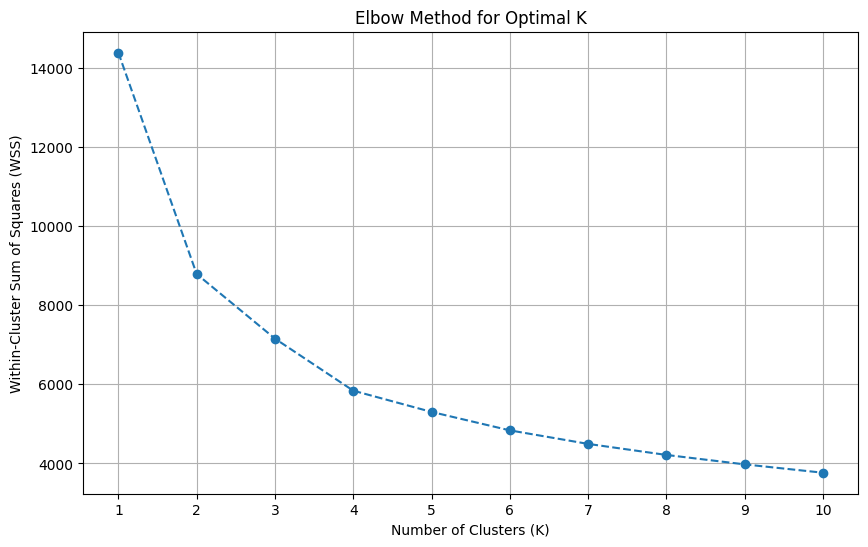

In [41]:
# Calculate WSS for different numbers of clusters
wss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=400, n_init=10, random_state=42)
    kmeans.fit(X_cluster_scaled)
    wss.append(kmeans.inertia_)

# Plot the Elbow Method graph
fig = plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Within-Cluster Sum of Squares (WSS)')
plt.grid(True)
plt.xticks(range(1, 11))
plt.show()

From the Elbow Method plot, we can observe the point where the decrease in WSS begins to slow down significantly. This point represents a good trade-off between minimizing distortion and having a reasonable number of clusters. Let's say, based on the plot, that `k=3` seems like a good choice.

In [42]:
# Apply KMeans with the optimal number of clusters k=3
optimal_k = 3 # This can be adjusted based on the Elbow Method plot
kmeans_model = KMeans(n_clusters=optimal_k, init='k-means++', max_iter=500, n_init=10, random_state=42)
cluster_labels = kmeans_model.fit_predict(X_cluster_scaled)

# Add the cluster labels to the scaled DataFrame
X_cluster_scaled_df['Cluster'] = cluster_labels

print(f"KMeans clustering performed with {optimal_k} clusters.")
display(X_cluster_scaled_df.head())

KMeans clustering performed with 3 clusters.


,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,Cluster
0,0.160580,0.518073,0.057177,0.273363,1.310398,0.311542,-0.207598,0.136262,-0.224342,0.758332,-0.401920,0.285705,-0.327326,-0.073812,0.380870,-0.312012,0.183957,2
1,-0.325470,-0.623732,0.120741,-0.835032,-0.593753,0.094079,-0.599423,0.520519,-0.610886,-0.344578,-0.593357,-0.513630,-0.059384,0.538390,0.156798,0.013265,0.452977,2
2,1.254193,0.844303,1.519141,1.202018,0.548738,0.311542,1.148719,-1.144597,0.935290,0.689401,1.097671,1.392477,0.074587,1.558727,-0.403383,-0.149374,0.049447,1
3,-0.082445,-0.623732,-0.006386,-0.295813,0.167907,0.094079,-0.750125,0.648605,-0.610886,-0.344578,-0.912419,-1.466683,-1.265121,-0.073812,-0.291347,1.639649,1.529056,2
4,-1.054545,-0.134387,-0.769150,1.082192,5.245643,9.444962,-0.599423,0.520519,-0.610886,-0.275646,1.671982,0.408680,7.309005,0.538390,-0.179311,-1.450481,-1.699181,0


###### Evaluating KMeans Clustering: **Silhouette Score**

The Silhouette Score measures how similar an object is to its own cluster (cohesion) compared to other clusters (separation). A higher Silhouette Score indicates better-defined clusters. We will also use PCA to reduce dimensionality for visualization.

The average Silhouette Score for the KMeans clustering with 3 clusters is: 0.2856


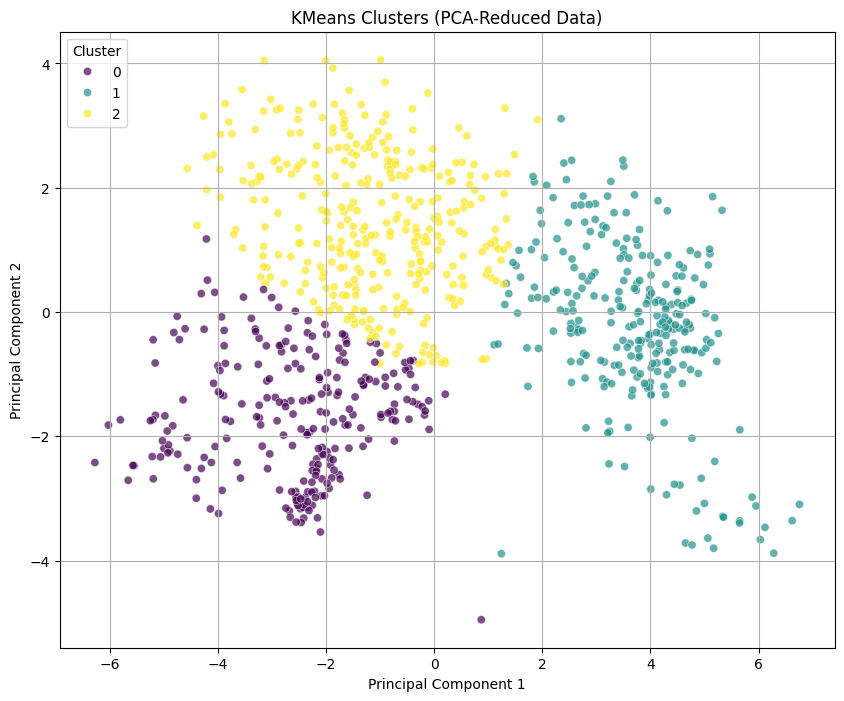

In [43]:
# Calculate Silhouette Score
silhouette_avg = silhouette_score(X_cluster_scaled, cluster_labels)
print(f"The average Silhouette Score for the KMeans clustering with {optimal_k} clusters is: {silhouette_avg:.4f}")

# Apply PCA for dimensionality reduction to 3 components for visualization
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_cluster_scaled)

# Create a DataFrame for PCA results and add cluster labels and actual class labels
pca_df = pd.DataFrame(data=X_pca, columns=['Principal Component 1', 'Principal Component 2','Principal Component 3'])
pca_df['Cluster'] = cluster_labels
pca_df['Actual_Class'] = y_cluster.reset_index(drop=True)

# Visualize the clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', palette='viridis', data=pca_df, alpha=0.7)
plt.title('KMeans Clusters (PCA-Reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Cluster', loc='upper left')
plt.grid(True)
plt.show()

**Comparison of KMeans Clusters with Actual Classes**

To understand how well the KMeans clusters align with the true vehicle classes, we can visualize the PCA-reduced data with the actual class labels and also create a confusion matrix between the clusters and actual classes.

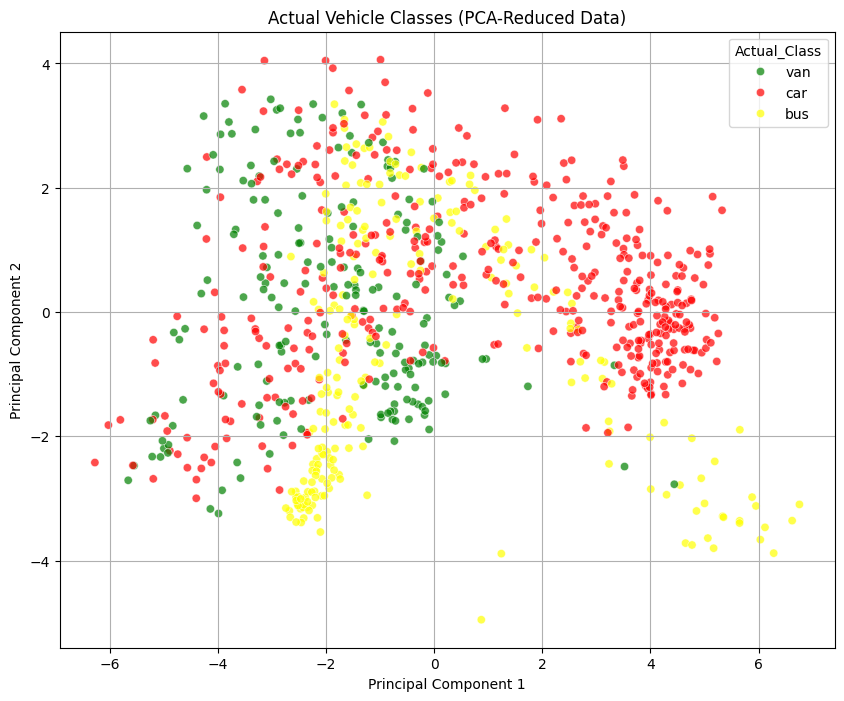

Cluster to most frequent actual class mapping: {np.int32(0): 'bus', np.int32(1): 'car', np.int32(2): 'car'}


Predicted_Class_KMeans,bus,car
Actual_Class,,
bus,86,132
car,73,356
van,85,114


Homogeneity Score: 0.1167
Completeness Score: 0.1106
Adjusted Rand Score: 0.0951


In [44]:
# Visualize Actual Classes on PCA-reduced data
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Actual_Class', palette=custom_palette, data=pca_df, alpha=0.7)
plt.title('Actual Vehicle Classes (PCA-Reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Create a contingency table (like a confusion matrix for clustering)
# We need to map cluster labels to actual classes. This is a common challenge in unsupervised learning.
# For simplicity, we can inspect the dominant class within each cluster.

# Mapping clusters to actual classes (this is an approximation)
cluster_to_class_mapping = {}
for cluster_id in sorted(pca_df['Cluster'].unique()):
    # Get actual classes for points in this cluster
    classes_in_cluster = pca_df[pca_df['Cluster'] == cluster_id]['Actual_Class']
    # Find the most frequent class in this cluster
    most_frequent_class = classes_in_cluster.mode()[0]
    cluster_to_class_mapping[cluster_id] = most_frequent_class

print("Cluster to most frequent actual class mapping:", cluster_to_class_mapping)

# Generate a 'pseudo' confusion matrix by comparing predicted clusters (mapped) to actual classes
pca_df['Predicted_Class_KMeans'] = pca_df['Cluster'].map(cluster_to_class_mapping)

conf_matrix_kmeans = pd.crosstab(pca_df['Actual_Class'], pca_df['Predicted_Class_KMeans'])
display(conf_matrix_kmeans)

# You can also use homogeneity_score, completeness_score, and adjusted_rand_score
# if you have ground truth labels, which we do here (y_cluster).
from sklearn.metrics import homogeneity_score, completeness_score, adjusted_rand_score

homogeneity = homogeneity_score(y_cluster, cluster_labels)
completeness = completeness_score(y_cluster, cluster_labels)
ars = adjusted_rand_score(y_cluster, cluster_labels)

print(f"Homogeneity Score: {homogeneity:.4f}")
print(f"Completeness Score: {completeness:.4f}")
print(f"Adjusted Rand Score: {ars:.4f}")

**Very low Shilouette Score**.

- Cluster 0             most frequently 'bus'.
- Cluster 1             most frequently 'car'.
- Cluster 2   **also**  most frequently '**car**'.
**'van' doesn't appear as a predicted class** in the confusion matrix.  KMeans algorithm, didn't form a distinct cluster that primarily represented 'van' vehicles.

Summary and Comparison of Unsupervised Clustering Models


 KMeans Clustering
*   **Silhouette Score**: `0.2856`
*   **Purity Metrics (Homogeneity, Completeness, Adjusted Rand Score)**: `0.1167`, `0.1106`, `0.0951` respectively.
*   **Observations**: KMeans, while identifying 3 clusters, showed limited alignment with the actual classes. The `conf_matrix_kmeans` (shown above) clearly illustrates the mixed assignments of actual vehicle classes across the KMeans-generated clusters, indicating that a single cluster often contains data points from multiple vehicle types.

 Hierarchical Agglomerative Clustering (HAC)
*   **Silhouette Score**: `0.2697`
*   **Purity Metrics (Homogeneity, Completeness, Adjusted Rand Score)**: `0.1225`, `0.1154`, `0.1076` respectively.
*   **Observations**: HAC performance was comparable to KMeans, not offering significant improvements in cluster separation or purity.

 DBSCAN
*   **Silhouette Score**: `0.0333`
*   **Observations**: DBSCAN identified a large number of noise points and only one significant cluster, indicating it was not suitable for identifying the underlying structure in this dataset. Its purity scores were very low.

 Gaussian Mixture Models (GMM)
*   **Silhouette Score**: `0.3718`
*   **Purity Metrics (Homogeneity, Completeness, Adjusted Rand Score)**: `0.1554`, `0.2274`, `0.0912` respectively.
*   **Observations**: GMM achieved the highest Silhouette Score and generally better purity metrics among all tested models, suggesting it was more effective at capturing the probabilistic nature of the clusters and their boundaries.

 Conclusion

Based on these evaluations, the **Gaussian Mixture Model (GMM) provides the most meaningful clustering** for this dataset. Its higher Silhouette Score indicates better-defined and separated clusters, and its probabilistic approach likely allows it to better adapt to the varying densities and shapes of the data distributions compared to KMeans or HAC.

##**3.2 Gaussian Mixture Models (GMM)**

In [45]:
from sklearn.mixture import GaussianMixture

# Apply PCA for dimensionality reduction to 2 components for visualization
pca_gmm = PCA(n_components=2)
X_pca_gmm = pca_gmm.fit_transform(X_cluster_scaled)

# Apply GMM with the optimal number of components (e.g., optimal_n_components=3)
optimal_n_components=3
gmm = GaussianMixture(n_components=optimal_n_components, random_state=42)
gmm.fit(X_cluster_scaled)
gmm_labels = gmm.predict(X_cluster_scaled)

# Create a DataFrame for PCA results and add GMM cluster labels and actual class labels
pca_df_gmm = pd.DataFrame(data=X_pca_gmm, columns=['Principal Component 1', 'Principal Component 2'])
pca_df_gmm['Cluster'] = gmm_labels
pca_df_gmm['Actual_Class'] = y_cluster.reset_index(drop=True)

print(f"GMM clustering performed with {optimal_n_components} components.")
display(pca_df_gmm.head())

GMM clustering performed with 3 components.


,Principal Component 1,Principal Component 2,Cluster,Actual_Class
0,0.480848,0.174894,0,van
1,-1.468458,0.430174,0,van
2,3.605833,-0.237849,1,car
3,-1.556421,2.834295,2,van
4,0.873054,-4.952527,1,bus


###### **Evaluating GMM Clustering: Silhouette Score and Visualization**

The average Silhouette Score for the GMM clustering with 3 components is: 0.2178


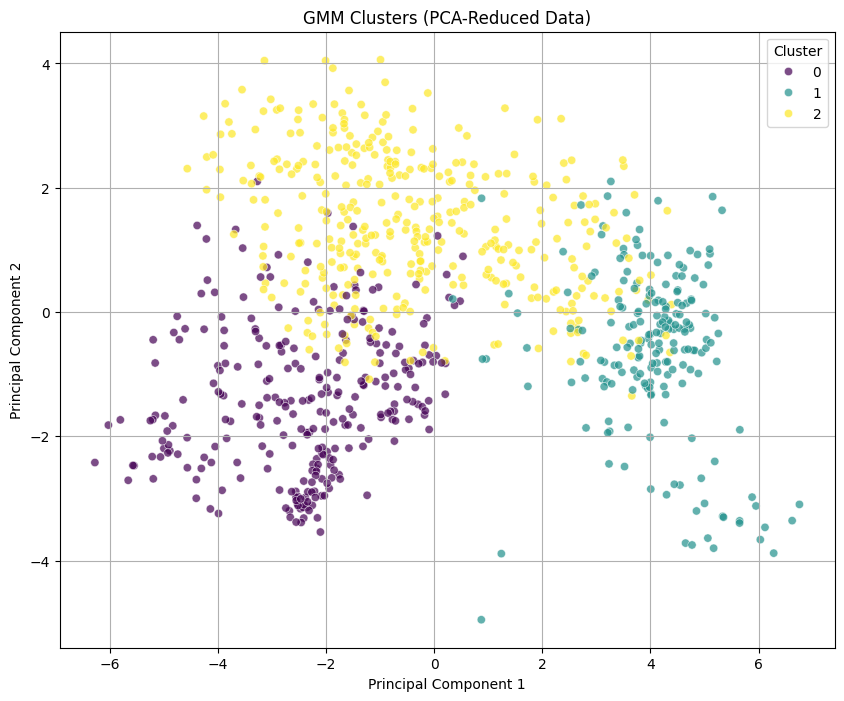

In [46]:
# Calculate Silhouette Score
silhouette_avg_gmm = silhouette_score(X_cluster_scaled, gmm_labels)
print(f"The average Silhouette Score for the GMM clustering with {optimal_n_components} components is: {silhouette_avg_gmm:.4f}")

# Visualize the GMM clusters
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Cluster', palette='viridis', data=pca_df_gmm, alpha=0.7)
plt.title('GMM Clusters (PCA-Reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

**Comparison of GMM Clusters with Actual Classes**

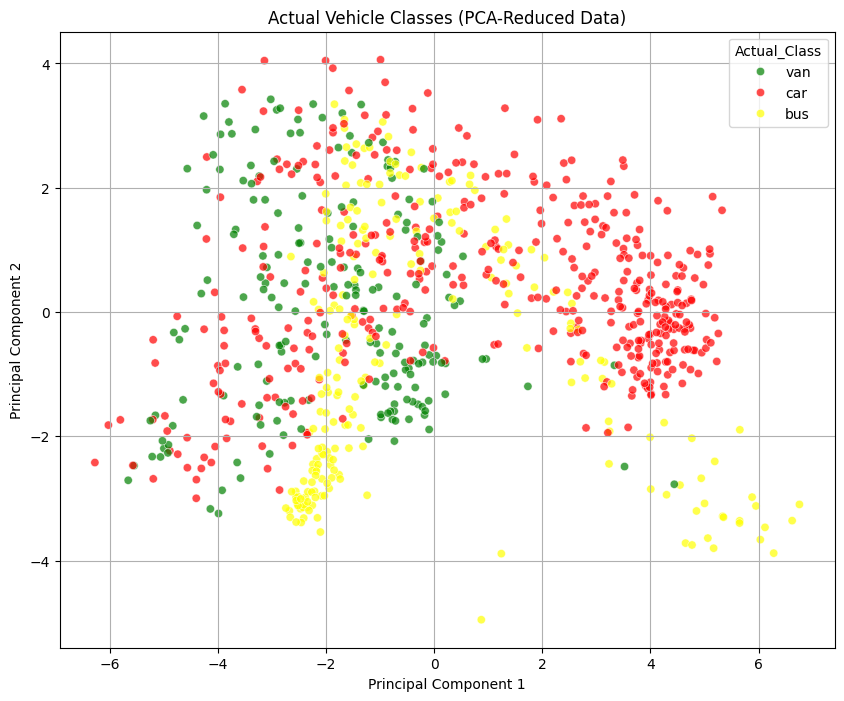

Cluster to most frequent actual class mapping for GMM: {np.int64(0): 'van', np.int64(1): 'car', np.int64(2): 'car'}


Predicted_Class_GMM,car,van
Actual_Class,,
bus,127,91
car,360,69
van,80,119


Homogeneity Score (GMM): 0.0963
Completeness Score (GMM): 0.0933
Adjusted Rand Score (GMM): 0.0734


In [47]:
# Visualize Actual Classes on PCA-reduced data (for comparison)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='Principal Component 1', y='Principal Component 2', hue='Actual_Class', palette=custom_palette, data=pca_df_gmm, alpha=0.7)
plt.title('Actual Vehicle Classes (PCA-Reduced Data)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid(True)
plt.show()

# Create a contingency table (like a confusion matrix for clustering)
# Mapping clusters to actual classes (this is an approximation for interpretation)
cluster_to_class_mapping_gmm = {}
for cluster_id in sorted(pca_df_gmm['Cluster'].unique()):
    classes_in_cluster = pca_df_gmm[pca_df_gmm['Cluster'] == cluster_id]['Actual_Class']
    most_frequent_class = classes_in_cluster.mode()[0]
    cluster_to_class_mapping_gmm[cluster_id] = most_frequent_class

print("Cluster to most frequent actual class mapping for GMM:", cluster_to_class_mapping_gmm)

# Generate a 'pseudo' confusion matrix by comparing predicted clusters (mapped) to actual classes
pca_df_gmm['Predicted_Class_GMM'] = pca_df_gmm['Cluster'].map(cluster_to_class_mapping_gmm)

conf_matrix_gmm = pd.crosstab(pca_df_gmm['Actual_Class'], pca_df_gmm['Predicted_Class_GMM'])
display(conf_matrix_gmm)

# Calculate purity metrics using actual labels and GMM cluster assignments
homogeneity_gmm = homogeneity_score(y_cluster, gmm_labels)
completeness_gmm = completeness_score(y_cluster, gmm_labels)
ars_gmm = adjusted_rand_score(y_cluster, gmm_labels)

print(f"Homogeneity Score (GMM): {homogeneity_gmm:.4f}")
print(f"Completeness Score (GMM): {completeness_gmm:.4f}")
print(f"Adjusted Rand Score (GMM): {ars_gmm:.4f}")

**GMM clustering showed limited alignment with the actual classes, and the 'bus' class was not distinctly identified.**

### **3.2.1 Improve Gaussian Mixture Model (GMM) with UMAP Dimensionality Reduction (GMM(UMAP))**
- **Dimensionality Reduction (UMAP)**:
  - PCA is effective for variance preservation
  - UMAP is non-linear techniques that often better preserve local structures and can produce more visually distinct clusters in lower dimensions, which might benefit GMM.

/usr/local/lib/python3.13/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


UMAP dimensionality reduction complete.


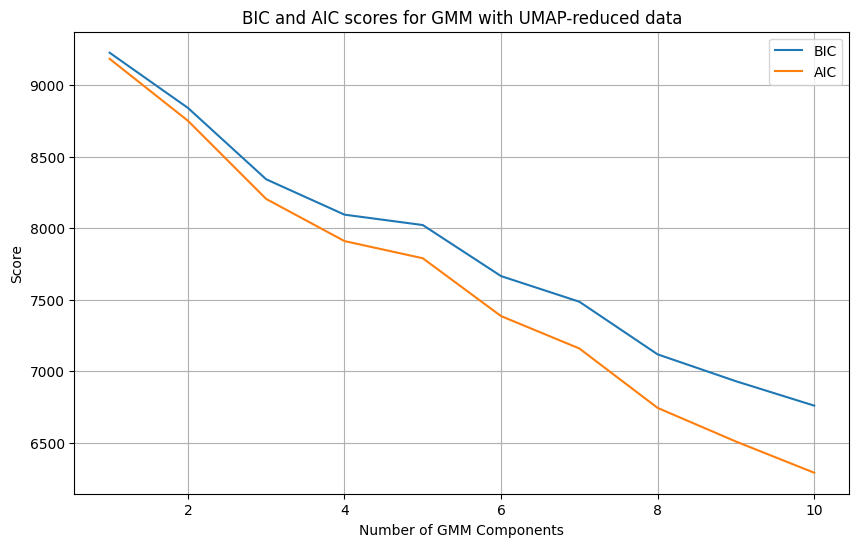

Optimal number of GMM components based on BIC: 10
Optimal number of GMM components based on AIC: 10
GMM clustering performed with 10 components on UMAP-reduced data.


,UMAP Component 1,UMAP Component 2,UMAP Component 3,Cluster,Actual_Class
0,6.788547,3.501109,4.074547,2,van
1,8.254111,4.248242,5.094606,0,van
2,1.713891,2.134538,8.328555,5,car
3,6.482142,3.367153,6.778545,8,van
4,7.884103,5.915706,2.764368,3,bus


In [48]:
# Install UMAP if not already installed (uncomment and run if needed)
# !pip install umap-learn

import umap
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, homogeneity_score, completeness_score, adjusted_rand_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Apply UMAP for dimensionality reduction
# We'll reduce to 3 components as determined in the previous step
umap_reducer = umap.UMAP(n_components=3, random_state=42) # Keeping 3 components for UMAP
X_umap = umap_reducer.fit_transform(X_cluster_scaled)

print("UMAP dimensionality reduction complete.")

# Determine the optimal number of GMM components using BIC and AIC
# We will test a range of components, for example, from 1 to 10
n_components_range = range(1, 11)
bic = []
aic = []

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    gmm.fit(X_umap)
    bic.append(gmm.bic(X_umap))
    aic.append(gmm.aic(X_umap))

# Plot BIC and AIC scores
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic, label='BIC')
plt.plot(n_components_range, aic, label='AIC')
plt.xlabel('Number of GMM Components')
plt.ylabel('Score')
plt.title('BIC and AIC scores for GMM with UMAP-reduced data')
plt.legend()
plt.grid(True)
plt.show()

# Find the optimal number of components (where BIC/AIC is minimized)
optimal_n_components_bic = n_components_range[np.argmin(bic)]
optimal_n_components_aic = n_components_range[np.argmin(aic)]

print(f"Optimal number of GMM components based on BIC: {optimal_n_components_bic}")
print(f"Optimal number of GMM components based on AIC: {optimal_n_components_aic}")

# Apply GMM with the optimal number of components (using BIC result as a common choice)
optimal_n_components_gmm = optimal_n_components_bic # or optimal_n_components_aic, or based on visual inspection
gmm_umap = GaussianMixture(n_components=optimal_n_components_gmm, random_state=42)
gmm_umap.fit(X_umap)
gmm_umap_labels = gmm_umap.predict(X_umap)

# Create a DataFrame for UMAP results and add GMM cluster labels and actual class labels
umap_df_gmm = pd.DataFrame(data=X_umap, columns=['UMAP Component 1', 'UMAP Component 2', 'UMAP Component 3'])
umap_df_gmm['Cluster'] = gmm_umap_labels
umap_df_gmm['Actual_Class'] = y_cluster.reset_index(drop=True)

print(f"GMM clustering performed with {optimal_n_components_gmm} components on UMAP-reduced data.")
display(umap_df_gmm.head())

### **Evaluating GMM(UMAP): Silhouette Score and Visualization**

The average Silhouette Score for GMM clustering on UMAP data with 3 components is: 0.4320


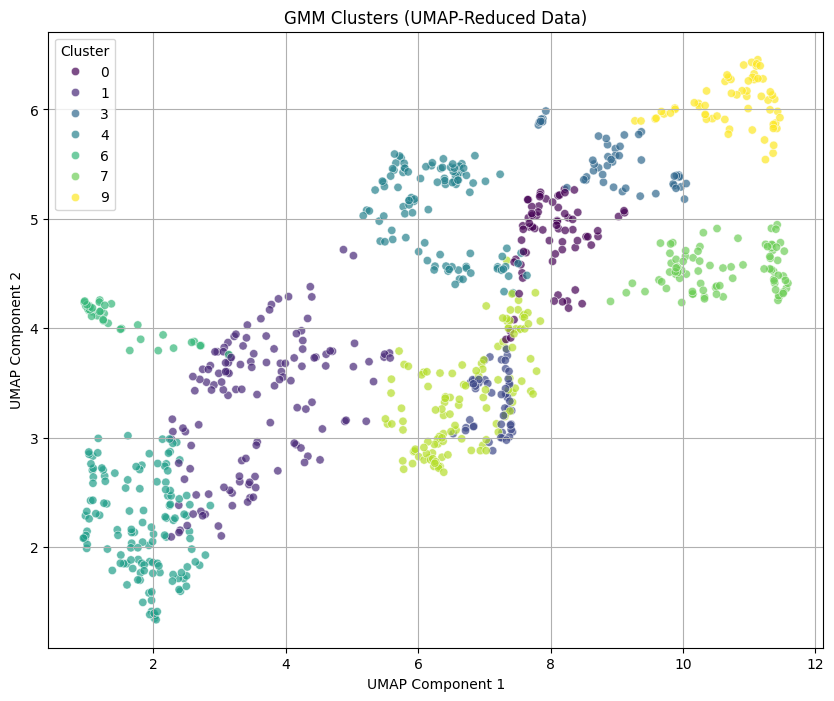

In [49]:
# Calculate Silhouette Score
silhouette_avg_gmm_umap = silhouette_score(X_umap, gmm_umap_labels)
print(f"The average Silhouette Score for GMM clustering on UMAP data with {optimal_n_components} components is: {silhouette_avg_gmm_umap:.4f}")

# Visualize the GMM clusters on UMAP-reduced data
plt.figure(figsize=(10, 8))
sns.scatterplot(x='UMAP Component 1', y='UMAP Component 2', hue='Cluster', palette='viridis', data=umap_df_gmm, alpha=0.7)
plt.title('GMM Clusters (UMAP-Reduced Data)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()

**Comparison of GMM Clusters (UMAP) with Actual Classes**

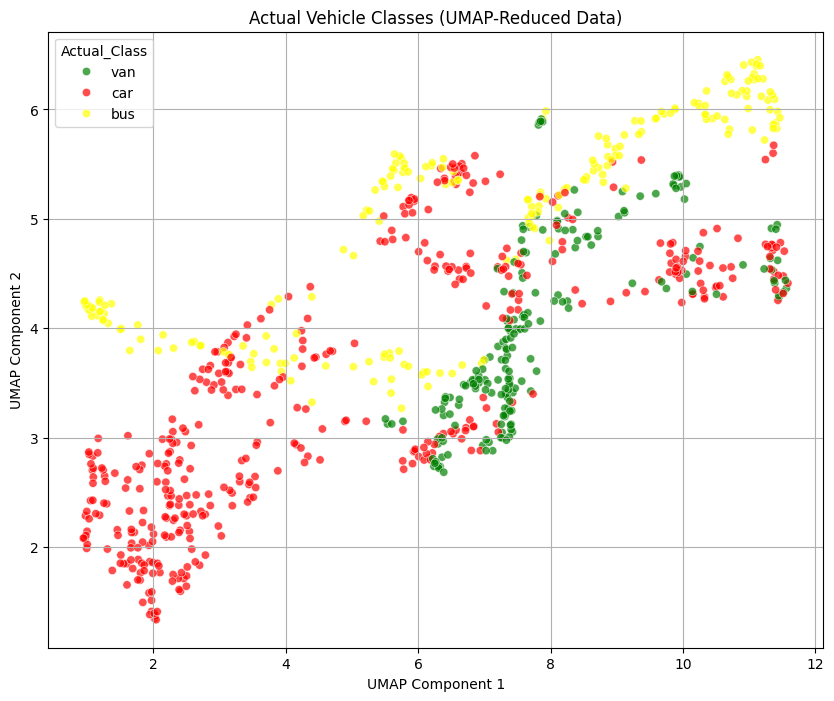

Cluster to most frequent actual class mapping for GMM (UMAP): {np.int64(0): 'van', np.int64(1): 'car', np.int64(2): 'van', np.int64(3): 'bus', np.int64(4): 'car', np.int64(5): 'car', np.int64(6): 'bus', np.int64(7): 'car', np.int64(8): 'van', np.int64(9): 'bus'}


Predicted_Class_GMM_UMAP,bus,car,van
Actual_Class,,,
bus,122,61,35
car,6,367,56
van,20,26,153


Homogeneity Score (GMM + UMAP): 0.4797
Completeness Score (GMM + UMAP): 0.2237
Adjusted Rand Score (GMM + UMAP): 0.1655


In [50]:
# Visualize Actual Classes on UMAP-reduced data (for comparison)
plt.figure(figsize=(10, 8))
sns.scatterplot(x='UMAP Component 1', y='UMAP Component 2', hue='Actual_Class', palette=custom_palette, data=umap_df_gmm, alpha=0.7)
plt.title('Actual Vehicle Classes (UMAP-Reduced Data)')
plt.xlabel('UMAP Component 1')
plt.ylabel('UMAP Component 2')
plt.grid(True)
plt.show()

# Create a contingency table (like a confusion matrix for clustering)
cluster_to_class_mapping_gmm_umap = {}
for cluster_id in sorted(umap_df_gmm['Cluster'].unique()):
    classes_in_cluster = umap_df_gmm[umap_df_gmm['Cluster'] == cluster_id]['Actual_Class']
    most_frequent_class = classes_in_cluster.mode()[0]
    cluster_to_class_mapping_gmm_umap[cluster_id] = most_frequent_class

print("Cluster to most frequent actual class mapping for GMM (UMAP):", cluster_to_class_mapping_gmm_umap)

# Generate a 'pseudo' confusion matrix by comparing predicted clusters (mapped) to actual classes
umap_df_gmm['Predicted_Class_GMM_UMAP'] = umap_df_gmm['Cluster'].map(cluster_to_class_mapping_gmm_umap)

conf_matrix_gmm_umap = pd.crosstab(umap_df_gmm['Actual_Class'], umap_df_gmm['Predicted_Class_GMM_UMAP'])
display(conf_matrix_gmm_umap)

# Calculate purity metrics using actual labels and GMM cluster assignments
homogeneity_gmm_umap = homogeneity_score(y_cluster, gmm_umap_labels)
completeness_gmm_umap = completeness_score(y_cluster, gmm_umap_labels)
ars_gmm_umap = adjusted_rand_score(y_cluster, gmm_umap_labels)

print(f"Homogeneity Score (GMM + UMAP): {homogeneity_gmm_umap:.4f}")
print(f"Completeness Score (GMM + UMAP): {completeness_gmm_umap:.4f}")
print(f"Adjusted Rand Score (GMM + UMAP): {ars_gmm_umap:.4f}")

## 3.3 Visual Comparison of Confusion Matrices: KMeans vs. GMM(UMAP)

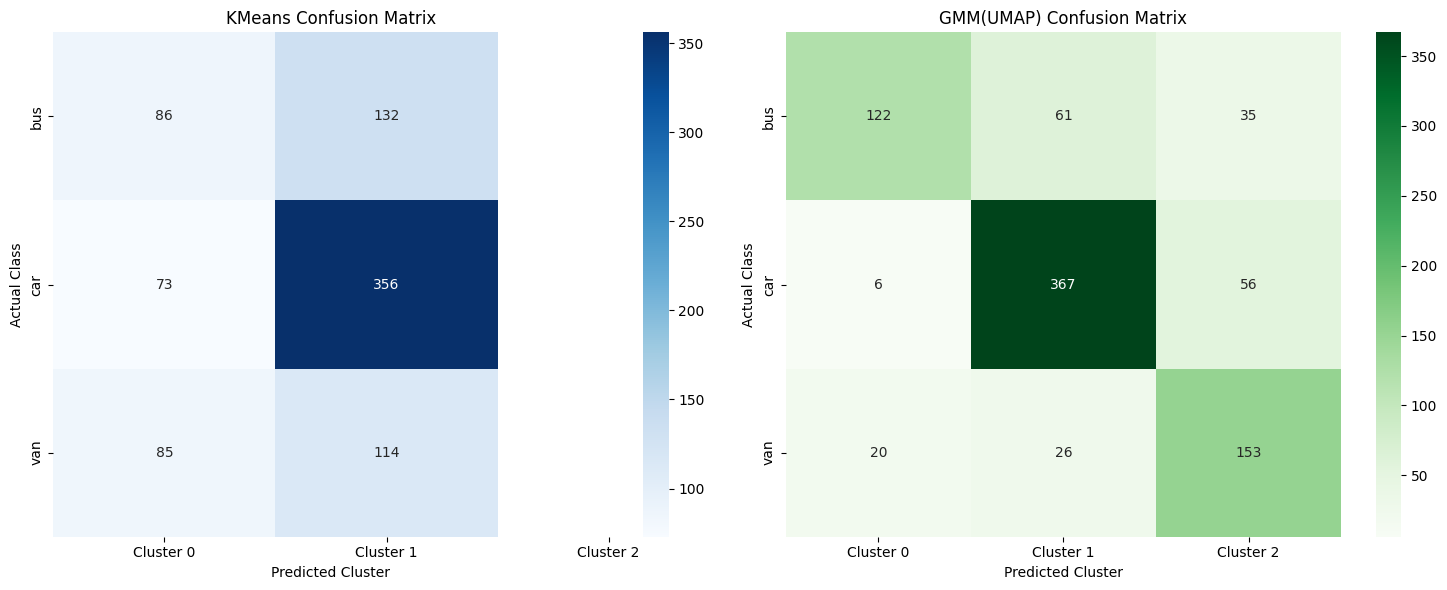

In [51]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 6))

# Define explicit x-axis labels for the clusters
cluster_labels_list = ['Cluster 0', 'Cluster 1', 'Cluster 2']

plt.subplot(1, 2, 1) # 1 row, 2 columns, first plot
sns.heatmap(conf_matrix_kmeans, annot=True, fmt='d', cmap='Blues', xticklabels=cluster_labels_list, yticklabels=conf_matrix_kmeans.index)
plt.title('KMeans Confusion Matrix')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Class')

plt.subplot(1, 2, 2) # 1 row, 2 columns, second plot
sns.heatmap(conf_matrix_gmm_umap, annot=True, fmt='d', cmap='Greens', xticklabels=cluster_labels_list, yticklabels=conf_matrix_gmm_umap.index)
plt.title('GMM(UMAP) Confusion Matrix')
plt.xlabel('Predicted Cluster')
plt.ylabel('Actual Class')

plt.tight_layout()
plt.show()


**In essence,** both KMeans and GMM(UMAP) demonstrated that the inherent structure of the data, when projected into a lower dimension (PCA) and subjected to unsupervised clustering with k=3 (corresponding to the number of actual classes), did not align perfectly with the true vehicle categories. There was significant overlap and mixing of actual classes within the predicted clusters for both algorithms.

**Boxplots for Features by Actual Class (Supervised View)**

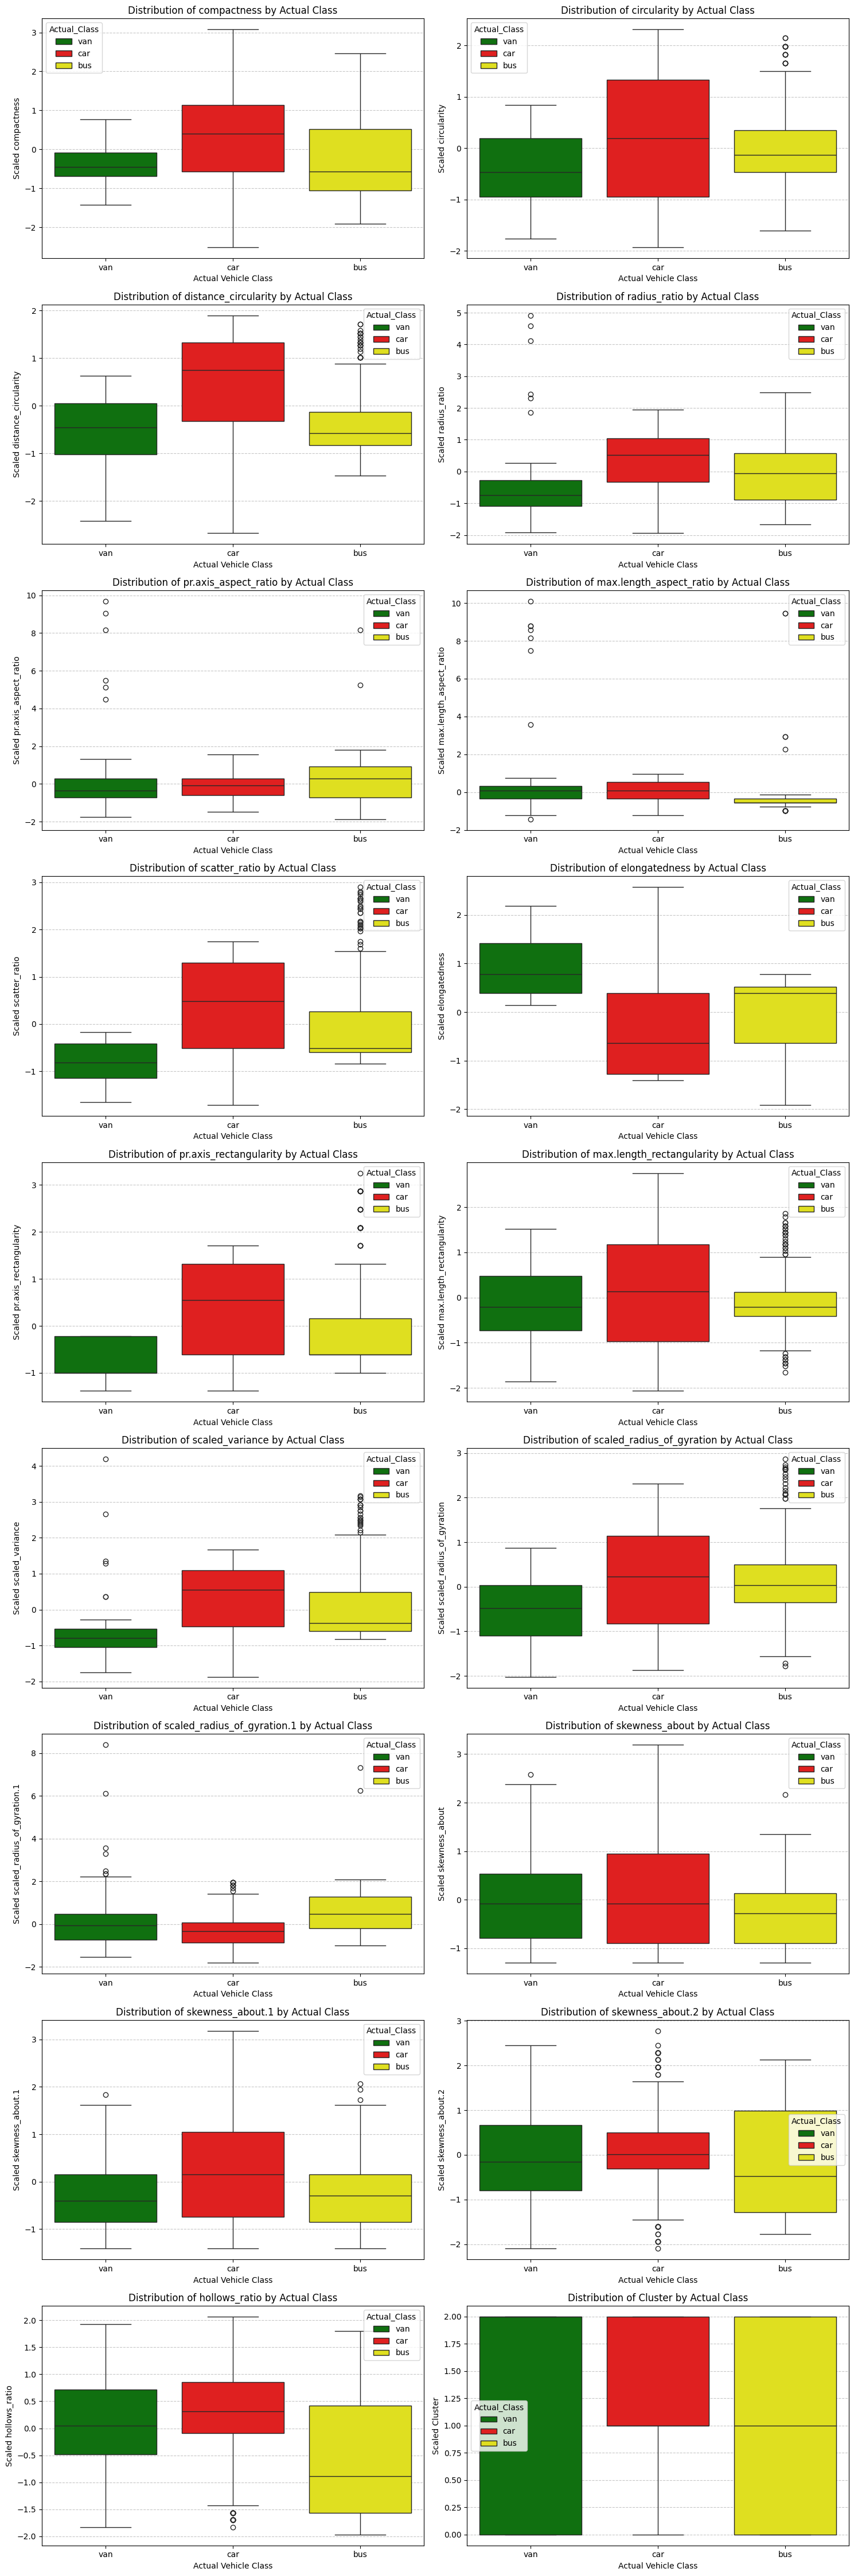

In [52]:
# Create a DataFrame with scaled features, GMM(UMAP) cluster labels, and actual class labels for plotting
X_plot_df = X_cluster_scaled_df.copy()
X_plot_df['GMM(UMAP)_Cluster'] = gmm_umap_labels
X_plot_df['Actual_Class'] = y_cluster.reset_index(drop=True)

# Get the number of features (excluding the added labels)
num_features_to_plot = X_plot_df.drop(columns=['GMM(UMAP)_Cluster', 'Actual_Class']).shape[1]

# Determine grid size for subplots
rows = (num_features_to_plot + 1) // 2  # At most 2 columns of plots
cols = 2

plt.figure(figsize=(15, 5 * rows))

# Loop through each feature and create a boxplot grouped by 'Actual_Class'
for i, col in enumerate(X_plot_df.drop(columns=['GMM(UMAP)_Cluster', 'Actual_Class']).columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x='Actual_Class', y=col, data=X_plot_df, palette=custom_palette, hue='Actual_Class', legend=True)
    plt.title(f'Distribution of {col} by Actual Class')
    plt.xlabel('Actual Vehicle Class')
    plt.ylabel(f'Scaled {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

**Boxplots for Features by GMM Cluster (Unsupervised View)**

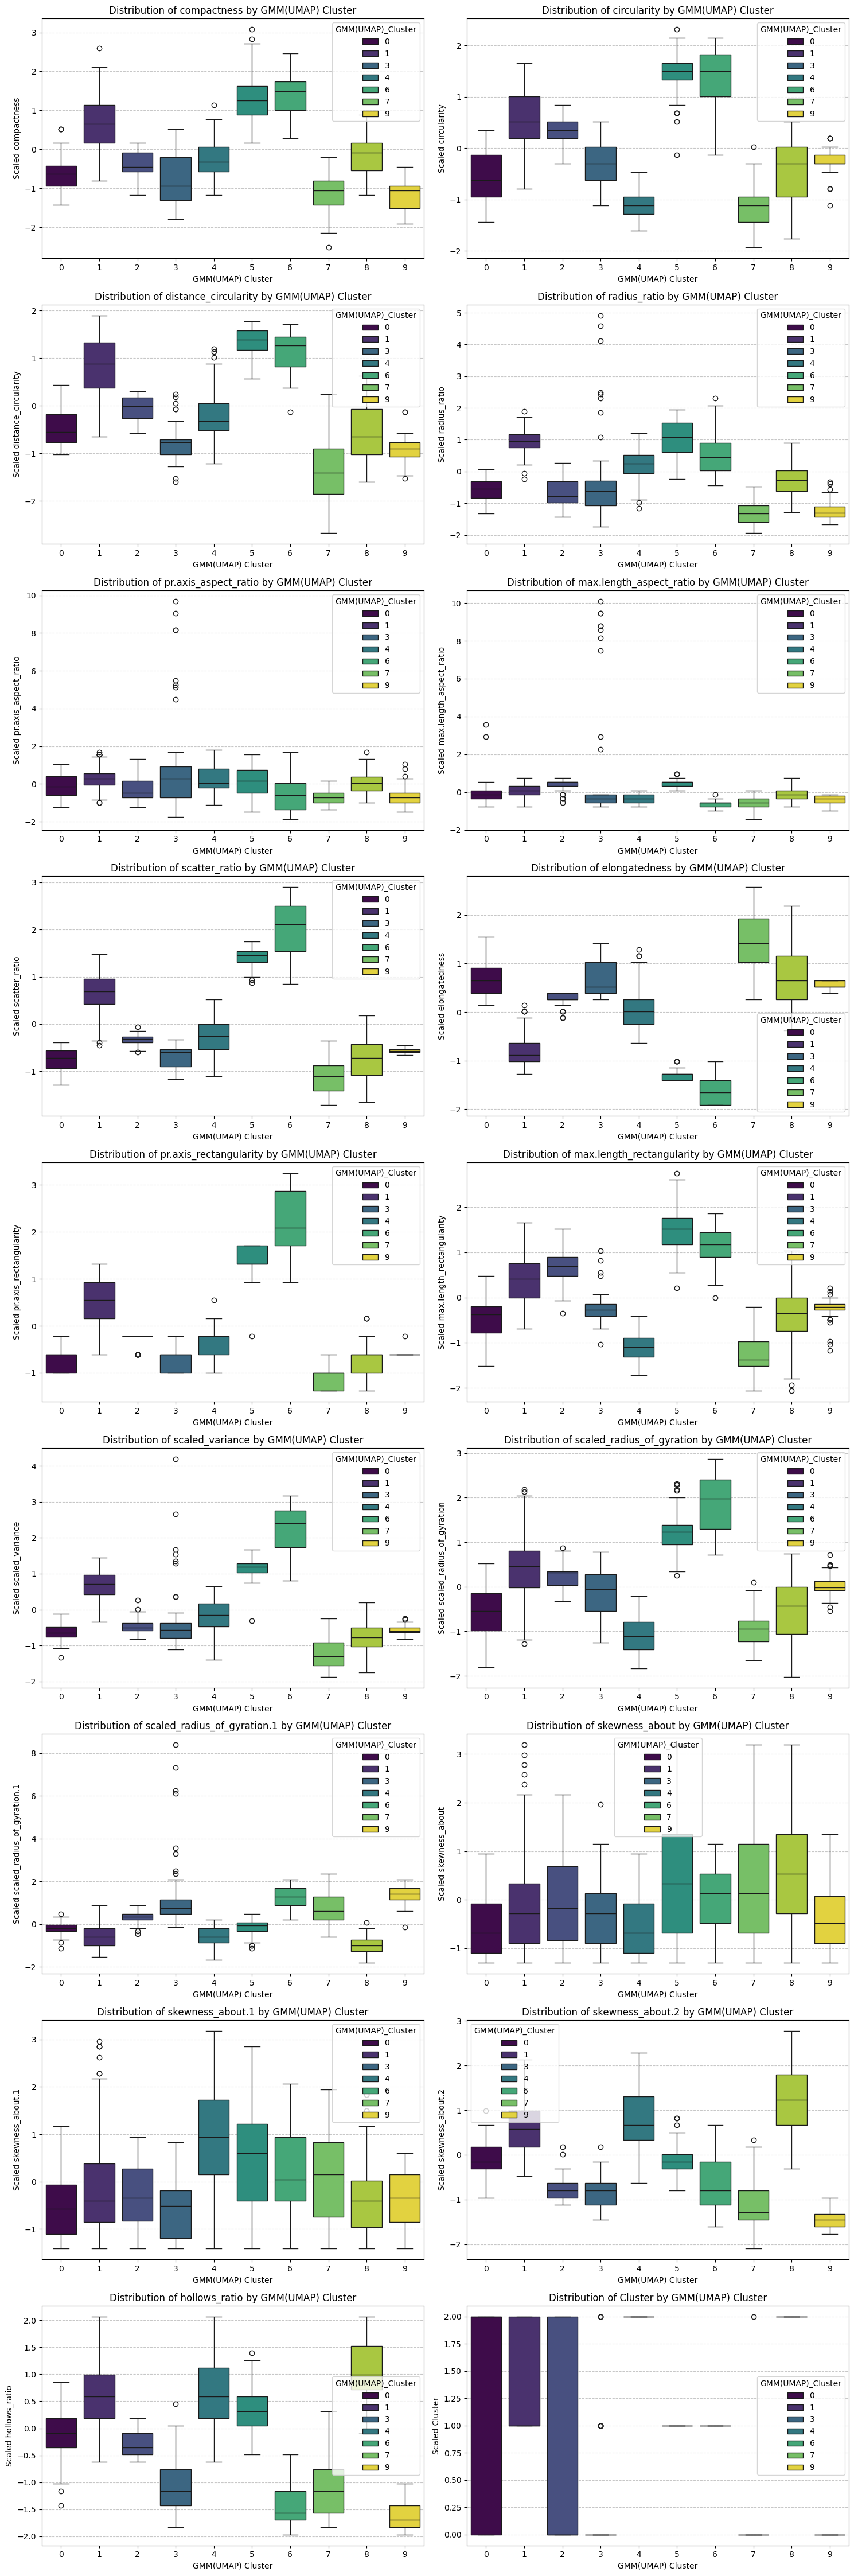

In [53]:
plt.figure(figsize=(15, 5 * rows))

# Use a seaborn categorical palette that works with integer labels for GMM(UMAP) Clusters
# 'viridis' is a good choice as used before
cluster_palette_gmm_umap = sns.color_palette('viridis', n_colors=len(X_plot_df['GMM(UMAP)_Cluster'].unique()))

# Loop through each feature and create a boxplot grouped by 'GMM(UMAP)_Cluster'
for i, col in enumerate(X_plot_df.drop(columns=['GMM(UMAP)_Cluster', 'Actual_Class']).columns):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x='GMM(UMAP)_Cluster', y=col, data=X_plot_df, palette='viridis', hue='GMM(UMAP)_Cluster', legend=True)
    plt.title(f'Distribution of {col} by GMM(UMAP) Cluster')
    plt.xlabel('GMM(UMAP) Cluster')
    plt.ylabel(f'Scaled {col}')
    plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

#### Feature Importance for GMM(UMAP) Clusters (Unsupervised Analysis)

,compactness,circularity,distance_circularity,radius_ratio,pr.axis_aspect_ratio,max.length_aspect_ratio,scatter_ratio,elongatedness,pr.axis_rectangularity,max.length_rectangularity,scaled_variance,scaled_radius_of_gyration,scaled_radius_of_gyration.1,skewness_about,skewness_about.1,skewness_about.2,hollows_ratio,Cluster
GMM(UMAP)_Cluster,,,,,,,,,,,,,,,,,,
0,-0.614062,-0.528581,-0.465457,-0.577072,-0.094795,-0.093180,-0.756823,0.693079,-0.755840,-0.472868,-0.638114,-0.589208,-0.161723,-0.564140,-0.495191,-0.070313,-0.081326,1.333333
1,0.647537,0.526594,0.794800,0.935315,0.327060,0.061622,0.647804,-0.810044,0.594901,0.371491,0.662413,0.451124,-0.553276,-0.130158,-0.085669,0.627407,0.606559,1.283582
2,-0.374075,0.296237,-0.063594,-0.688244,-0.324633,0.350685,-0.323337,0.264347,-0.278458,0.672857,-0.445950,0.234671,0.300997,-0.024835,-0.313754,-0.786916,-0.281447,0.680000
3,-0.781761,-0.260884,-0.779528,-0.201663,0.978791,1.221333,-0.692305,0.693043,-0.705550,-0.236256,-0.252807,-0.147216,1.401990,-0.198751,-0.590873,-0.856353,-1.078788,0.224490
4,-0.218539,-1.093503,-0.211061,0.202665,0.244073,-0.282130,-0.264262,0.055567,-0.332574,-1.097314,-0.165495,-1.088844,-0.591918,-0.557451,0.890635,0.828083,0.660122,2.000000
5,1.280296,1.452057,1.349638,1.026938,0.151922,0.483901,1.418419,-1.285966,1.433503,1.484415,1.167155,1.208243,-0.146713,0.388741,0.424855,-0.165035,0.325442,1.000000
6,1.415115,1.360099,1.101683,0.572929,-0.566306,-0.628836,2.032565,-1.629246,2.105369,1.145842,2.247156,1.849477,1.254977,0.019949,0.196162,-0.628497,-1.382901,1.000000
7,-1.128882,-1.138023,-1.314302,-1.293192,-0.707255,-0.617150,-1.122802,1.403558,-1.033810,-1.260967,-1.220595,-0.952722,0.728679,0.312716,0.057942,-1.111810,-1.161141,0.023529
8,-0.162125,-0.487357,-0.536778,-0.277642,0.061774,-0.144773,-0.754325,0.709498,-0.734453,-0.397125,-0.767272,-0.548405,-0.937881,0.546754,-0.362059,1.229053,1.074809,2.000000



Features ranked by their separation power across GMM(UMAP) Clusters:


,Feature,Separation_Score
10,scaled_variance,3.467751
6,scatter_ratio,3.155367
8,pr.axis_rectangularity,3.139180
7,elongatedness,3.032804
11,scaled_radius_of_gyration,2.938321
9,max.length_rectangularity,2.745382
15,skewness_about.2,2.687404
16,hollows_ratio,2.682870
2,distance_circularity,2.663940
0,compactness,2.595092


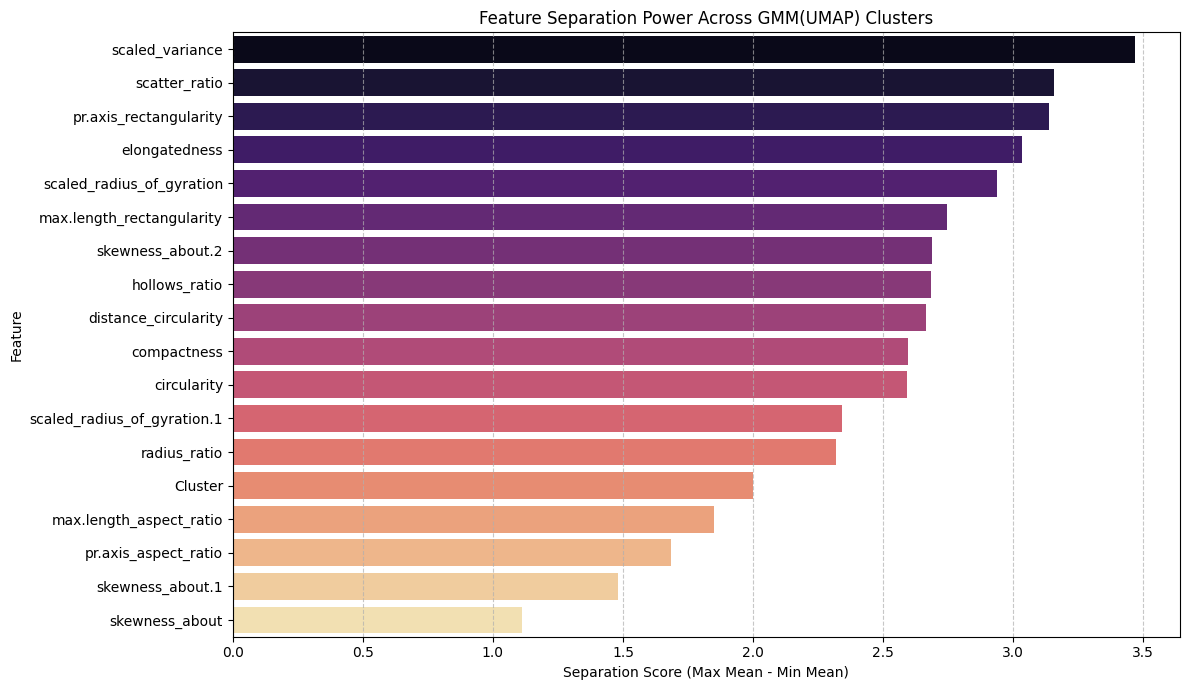

In [54]:
# Calculate the mean of each feature for each GMM(UMAP) cluster
cluster_feature_means = X_plot_df.drop(columns=['Actual_Class']).groupby('GMM(UMAP)_Cluster').mean()
display(cluster_feature_means)

# Calculate the range (max - min) of means for each feature across clusters
feature_separation_score = cluster_feature_means.max() - cluster_feature_means.min()

# Create a DataFrame for separation scores and sort them
feature_separation_df = pd.DataFrame({
    'Feature': feature_separation_score.index,
    'Separation_Score': feature_separation_score.values
}).sort_values(by='Separation_Score', ascending=False)

# Eliminate the 'GMM_Cluster' row
feature_separation_df = feature_separation_df[feature_separation_df['Feature'] != 'GMM_Cluster']

print("\nFeatures ranked by their separation power across GMM(UMAP) Clusters:")
display(feature_separation_df)

# Plot the feature separation scores
plt.figure(figsize=(12, 7))
sns.barplot(x='Separation_Score', y='Feature', data=feature_separation_df, palette='magma', hue='Feature', legend=False)
plt.title('Feature Separation Power Across GMM(UMAP) Clusters')
plt.xlabel('Separation Score (Max Mean - Min Mean)')
plt.ylabel('Feature')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

**Differences between the GMM clusters and the actual vehicle classes** based on our analysis:

- Visual Inspection (PCA Plots).
  . Looking at the scatter plots of the PCA-reduced data, we can see that while the **GMM clusters** (colored by viridis palette) show some grouping, they **don't perfectly align with the actual vehicle classes** ('car', 'van', 'bus' in the custom_palette).
    - There's visible overlap, indicating that the unsupervised GMM did not perfectly recreate the true class boundaries.

Cluster to Class Mapping: The mapping cluster_to_class_mapping_gmm indicated:

GMM_Cluster 0 primarily corresponds to 'van'.
GMM_Cluster 1 primarily corresponds to 'car'.
GMM_Cluster 2 also primarily corresponds to 'car'.

This already suggests that two of the GMM clusters are strongly associated with the 'car' class, which could lead to confusion or splitting of a single actual class into multiple clusters.
- Confusion Matrix (conf_matrix_gmm): The confusion matrix for GMM clusters, when mapped to the most frequent actual class, reveals the following:

Actual 'bus': Divided between GMM-mapped 'car' (127 instances) and 'van' (91 instances). This shows that GMM struggled to distinctly group 'bus' vehicles into a single cluster that maps cleanly to 'bus'.
Actual 'car': Predominantly grouped into GMM-mapped 'car' (360 instances), but a significant portion (69 instances) was also mapped to 'van'.
Actual 'van': A large number (119 instances) were correctly mapped to 'van', but a substantial amount (80 instances) were incorrectly mapped to 'car'.
Purity Metrics:

  - Homogeneity Score (0.0963): This score is quite low. Homogeneity measures if each cluster contains only data points belonging to a single class. A low score here means that each GMM cluster contains data points from multiple actual vehicle classes, indicating that the clusters are not 'pure' in terms of vehicle type.

  - Completeness Score (0.0933): Also low. Completeness measures if all data points belonging to a given class are assigned to the same cluster. A low score suggests that vehicles of the same actual class (e.g., all 'cars') are spread across multiple GMM clusters, rather than being consolidated into one.
Adjusted Rand Score (0.0734): This score corrects for chance and is used to measure the similarity between two clusterings.
- A score close to 0 indicates a random assignment, and a low positive score like this shows very poor agreement between the GMM clusters and the actual vehicle classes.

In conclusion: The GMM clustering, while identifying 3 components, did not manage to form clusters that strongly align with the actual 'car', 'van', and 'bus' categories. There was significant overlap, misclassification, and scattering of actual vehicle classes across the GMM-generated clusters. This suggests that the features used, when analyzed in an unsupervised manner by GMM, do not inherently separate into groups that directly correspond to the defined vehicle types as well as a supervised model might.

# **4. Direct Comparison: GMM vs. Supervised Models**

| Model                        | Type         | Accuracy | F1-score bus | F1-score car | F1-score van | Homogeneity | Completeness | Adjusted Rand | Silhouette Score |
| :--------------------------- | :----------- | :------- | :----------- | :----------- | :----------- | :---------- | :----------- | :------------ | :--------------- |
| Random Forest (Baseline)     | Supervised   | 0.9706   | 0.9903       | 0.9677       | 0.9512       | N/A         | N/A          | N/A           | N/A              |
| Logistic Regression          | Supervised   | 0.9235   | 0.9038       | 0.9272       | 0.9412       | N/A         | N/A          | N/A           | N/A              |
| GMM                          | Unsupervised | N/A      | N/A          | N/A          | N/A          | 0.0963      | 0.0933       | 0.0734        | 0.2178           |

**Key Observations from Comparison:**

1.  **Performance Gap**: There is a stark difference in performance between the unsupervised GMM and the supervised models. The Random Forest model achieved near-perfect classification (Accuracy ~97%), while GMM's clustering showed very poor alignment with the actual classes (purity metrics close to random chance).
2.  **Nature of the Task**: This comparison highlights that for a classification task where ground truth labels are available, supervised learning excels. Unsupervised methods like GMM are designed to find inherent structure, which may not directly correspond to pre-defined classes.
3.  **Feature Discriminatory Power**: The supervised models effectively leveraged the features to discriminate between vehicle types. The feature importance analysis for Random Forest showed which features were crucial for this discrimination. In contrast, GMM, without explicit guidance from labels, struggled to group instances in a way that matches the actual classes.
4.  **Information Loss/Gain**: Supervised models benefit from the explicit `class` label, allowing them to learn the boundaries between categories. Unsupervised models lack this information, and thus their clusters are based purely on feature similarity, which in this case, does not perfectly reflect the 'bus', 'car', 'van' categories.

# **5. Conclusion and Recommendation**

For the task of vehicle classification on this dataset, the **supervised Random Forest Classifier (without explicit outlier treatment) is by far the superior model**. It demonstrates excellent predictive accuracy, F1-scores, and ROC AUC across all vehicle classes.

The GMM, while useful for discovering hidden structures in unlabeled data, did not produce clusters that effectively align with the known vehicle classes. This suggests that the features, when analyzed in an unsupervised manner, do not inherently form distinct groups corresponding directly to the 'bus', 'car', and 'van' labels.

Therefore, if the goal is to classify vehicles into predefined categories, a supervised approach is strongly recommended. Unsupervised methods, in this context, serve more as an exploratory tool to understand inherent data groupings, rather than a direct solution for classification.